#Data Sparsity treatment for Context-Aware Recommender System (CARS) - InCarMusic
Analysis and treatment of Data Sparsity in InCarMusic dataset.

Author: Gustavo Fleury Soares

Project: <<https://github.com/gustavofleury/DataSparsity_treat_ContextAware_RS>>

In [ ]:
#Paths
DATASETS_FOLDER = '/content/drive/My Drive/CARS/Datasets'
COLAB_FOLDER = '/content/drive/My Drive/Colab Notebooks/'

In [ ]:
# If load EXCEL file from internet give error
# Downgrade pandas
!pip install pandas==1.0.1

     |████████████████████████████████| 10.1MB 3.1MB/s 
ERROR: google-colab 1.0.0 has requirement pandas~=1.1.0; python_version >= "3.0", but you'll have pandas 1.0.1 which is incompatible.
ERROR: fbprophet 0.7.1 has requirement pandas>=1.0.4, but you'll have pandas 1.0.1 which is incompatible.
  Found existing installation: pandas 1.1.2
    Uninstalling pandas-1.1.2:
      Successfully uninstalled pandas-1.1.2


In [ ]:
#Run Functions from another Jupyter Notebook
%run '/content/drive/My Drive/Colab Notebooks/CARS-FUNCTIONS.ipynb'

Ign:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Ign:2 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release
Hit:4 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release
Hit:5 http://security.ubuntu.com/ubuntu bionic-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu bionic InRelease
Hit:7 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu bionic InRelease
Hit:8 http://archive.ubuntu.com/ubuntu bionic-updates InRelease
Hit:10 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran40/ InRelease
Hit:11 http://archive.ubuntu.com/ubuntu bionic-backports InRelease
Hit:12 http://ppa.launchpad.net/graphics-drivers/ppa/ubuntu bionic InRelease
Reading package lists... Done
openjdk version "11.0.8" 2020-07-14
OpenJDK Runtime Environment (build 11.0.8+10-post-Ubuntu-0ubunt

In [ ]:
# df = pd.read_csv('Data_STS.csv', sep='\t', lineterminator='\n')
# df = pd.ExcelFile('Data_InCarMusic.xlsx').parse('ContextualRating');

fileUrl = 'https://github.com/UCM-GAIA/Context-Dataset/raw/master/datasets/Music_InCarMusic/Data_InCarMusic.xlsx'
df = pd.ExcelFile(fileUrl).parse('ContextualRating');
dfOri=df.copy()

#Separete TRAIN and TEST
np.random.seed(2)
msk = np.random.rand(len(df)) < 0.8
df_train = df[msk]
df_test = df[~msk]
print(len(df_train),' - ', len(df_test))


3216  -  796


In [ ]:
dfOri

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Profiling

In [ ]:
prof = ProfileReport(df)

TypeError: ignored

In [ ]:
prof

In [ ]:
#Count Nan values
df.isna().sum()

UserID                  0
ItemID                  0
 Rating                 0
DrivingStyle         3659
landscape            3507
mood                 3606
naturalphenomena     3616
RoadType             3616
sleepiness           3855
trafficConditions    3613
weather              3615
dtype: int64

In [ ]:
len(df.columns)

11

In [ ]:
len(df)

4012

In [ ]:
df.isna().sum().sum()

29087

In [ ]:
len(df)*(len(df.columns) -3) # Minus UserID, ItemID and Ratings (CREATIONDATA)

32096

In [ ]:
100*(df.isna().sum().sum())/(len(df)*(len(df.columns) -3))

90.625

In [ ]:
# SEGMENT to analyse.
df2 = df.loc[df.DrivingStyle=='relaxed driving']
len(df2)

181

In [ ]:
df2.isna().sum()

UserID                 0
ItemID                 0
 Rating                0
DrivingStyle           0
landscape            181
mood                 181
naturalphenomena     181
RoadType             181
sleepiness           181
trafficConditions    181
weather              181
dtype: int64

In [ ]:
# SEGMENT to analyse.
df3 = df.loc[~df.landscape.isna()]
len(df3)

505

In [ ]:
df3

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
23,1001,251,2,NaN,urban,NaN,NaN,NaN,NaN,NaN,NaN
24,1001,294,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
25,1001,674,3,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
26,1001,267,4,NaN,country side,NaN,NaN,NaN,NaN,NaN,NaN
27,1001,694,4,NaN,coast line,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3993,1042,709,1,NaN,country side,NaN,NaN,NaN,NaN,NaN,NaN
3994,1042,682,1,NaN,coast line,NaN,NaN,NaN,NaN,NaN,NaN
3995,1042,716,1,NaN,coast line,NaN,NaN,NaN,NaN,NaN,NaN
3996,1042,753,1,NaN,coast line,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df3.isna().sum()

In [ ]:
def calculate_sparsity(dfA):
  return 100*(dfA.isna().sum().sum())/(len(dfA)*(len(dfA.columns) -3))

In [ ]:
calculate_sparsity(df3)

87.5

In [ ]:
# VERIFY IF there are COLUMNS line iteractions
for c in df.columns:
  df3 = df.loc[~df[c].isna()]
  print('XXXXX - ', c , ' Sparsity: ', calculate_sparsity(df3) )
  lines=len(df3)
  for c in df3.columns:
    numValues = lines - df3[c].isna().sum()
    print('  ' + c + ' - ' + str(numValues))

XXXXX -  UserID  Sparsity:  90.625
  UserID - 4012
  ItemID - 4012
   Rating - 4012
  DrivingStyle - 353
  landscape - 505
  mood - 406
  naturalphenomena  - 396
  RoadType - 396
  sleepiness - 157
  trafficConditions - 399
  weather - 397
XXXXX -  ItemID  Sparsity:  90.625
  UserID - 4012
  ItemID - 4012
   Rating - 4012
  DrivingStyle - 353
  landscape - 505
  mood - 406
  naturalphenomena  - 396
  RoadType - 396
  sleepiness - 157
  trafficConditions - 399
  weather - 397
XXXXX -   Rating  Sparsity:  90.625
  UserID - 4012
  ItemID - 4012
   Rating - 4012
  DrivingStyle - 353
  landscape - 505
  mood - 406
  naturalphenomena  - 396
  RoadType - 396
  sleepiness - 157
  trafficConditions - 399
  weather - 397
XXXXX -  DrivingStyle  Sparsity:  87.5
  UserID - 353
  ItemID - 353
   Rating - 353
  DrivingStyle - 353
  landscape - 0
  mood - 0
  naturalphenomena  - 0
  RoadType - 0
  sleepiness - 0
  trafficConditions - 0
  weather - 0
XXXXX -  landscape  Sparsity:  87.5
  UserID - 505
 

#Try to FIND SEGMENT

In [ ]:
df=dfOri
df['UI']=df.UserID.astype(str) + '-' + df.ItemID.astype(str)

In [ ]:
# df.UI.nunique()
# len(df)
# for c in df.columns:
#   print('X'+c+'X')
df[ (df.landscape=='mountains') & (df[' Rating'] >=4)]


,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
24,1001,294,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
538,1006,286,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
540,1006,266,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
541,1006,261,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
724,1007,260,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
1347,1012,750,5,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
1353,1012,273,4,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
2112,1019,689,5,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
2118,1019,283,5,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN
2124,1019,260,5,NaN,mountains,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
calculate_sparsity(df[ (df.landscape=='mountains') & (df[' Rating'] >=4)])

87.5

#WORD 2 Vector

In [ ]:
#LOAD MODEL
# Options:
#     wiki.en (default)
#     cc.

# ft = load_w2v_model('wiki.en')
ft = load_w2v_model('dbpedia')

In [ ]:
!ls /content/drive/My\ Drive/CARS/Datasets |grep bin

dbpedia.bin
wiki.en.bin


In [ ]:
ft.get_dimension()

10

In [ ]:
ft.get_word_vector('mountain')

array([1.5404919 , 0.77612454, 2.0214124 , 1.6264899 , 0.4112101 ,
       1.9224739 , 1.617044  , 0.94564897, 0.21580234, 5.085126  ],
      dtype=float32)

In [ ]:
ft.get_nearest_neighbors('mountain')

[(0.8582334518432617, 'mountain—'),
 (0.8294317722320557, 'mountain»'),
 (0.8263961672782898, '—mountain'),
 (0.8255876302719116, 'mountain,'),
 (0.8182247877120972, 'mountains…'),
 (0.8121200799942017, '#mountain'),
 (0.8109002709388733, '\u3000mountain'),
 (0.8063478469848633, '‘mountain'),
 (0.8042652010917664, 'mountains'),
 (0.8042367696762085, 'mountain—a')]

#PLOTTING (each Variable)

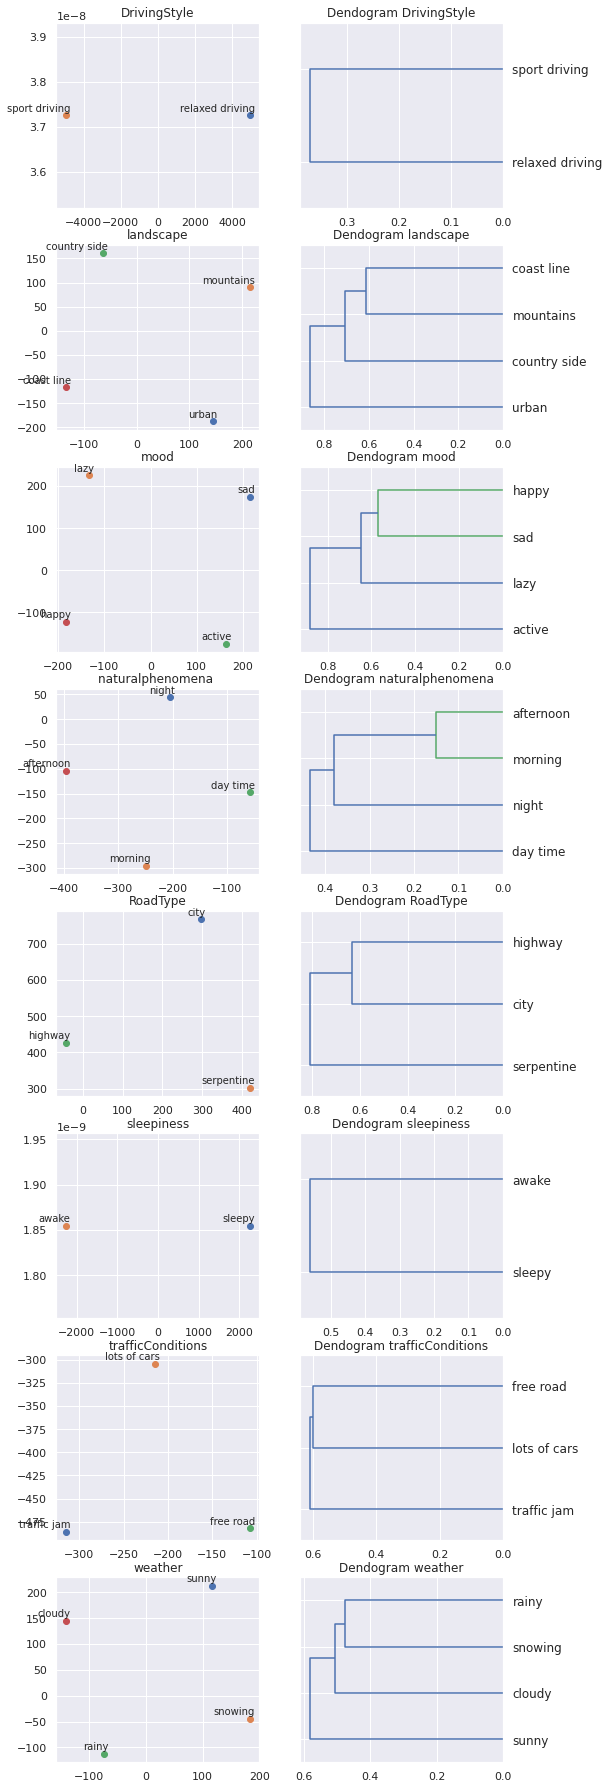

In [ ]:
df = dfOri.copy()
plot_w2v_dendogram(df.columns[3:], ft, fig_size=4)

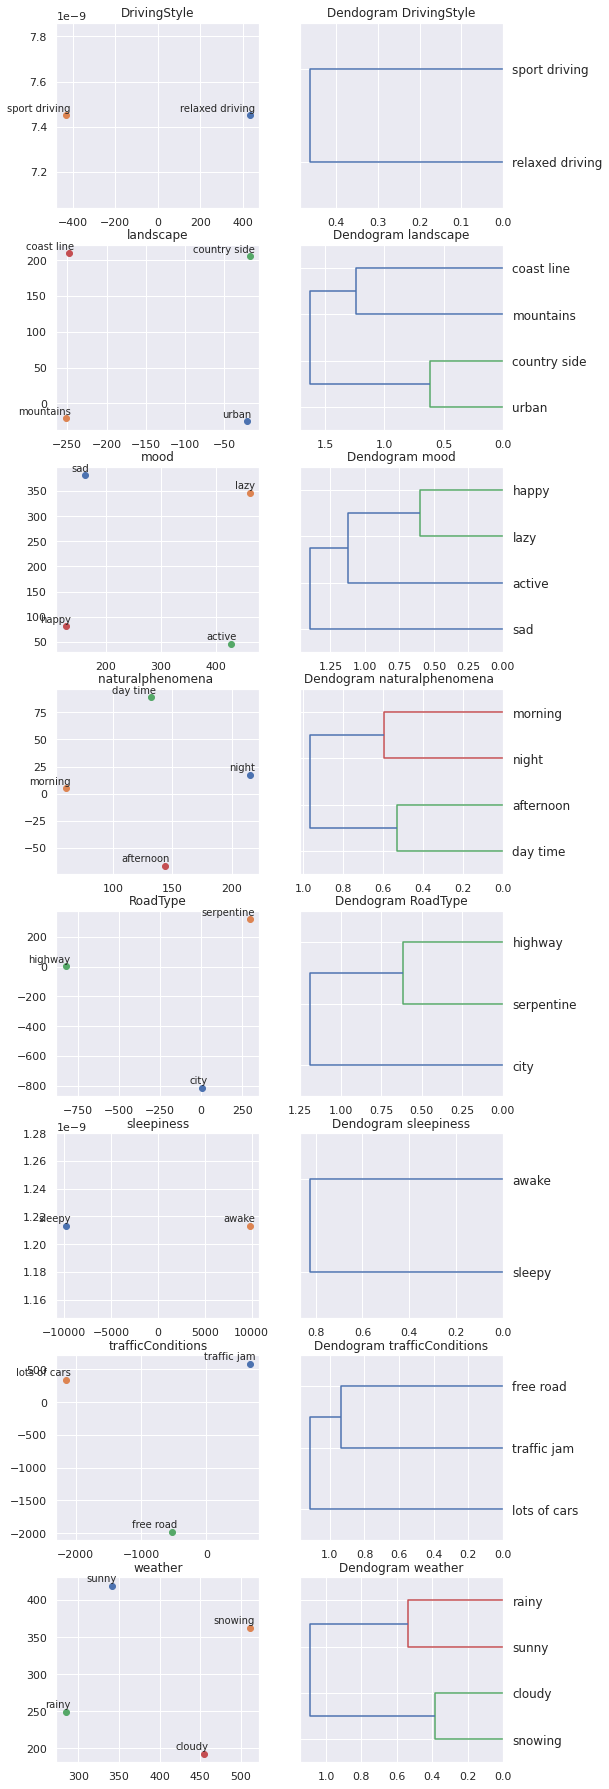

In [ ]:
#Plot DBPedia
df = dfOri.copy()
plot_w2v_dendogram(df.columns[3:], ft, 4)

#PLOTTING Titles Relations

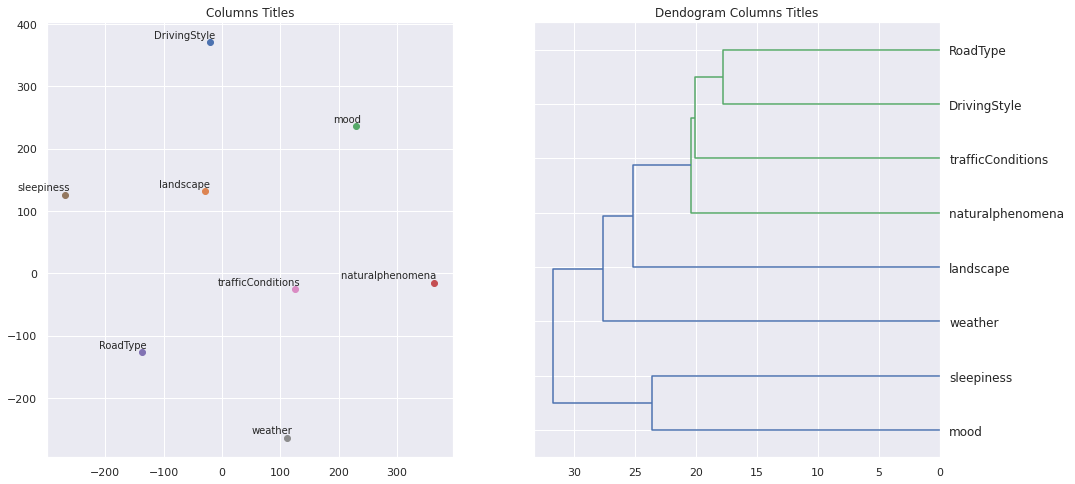

In [ ]:
plot_w2v_dendogram_Titles(df.columns[3:], ft, 8)

#Plottings ALL-Togheter

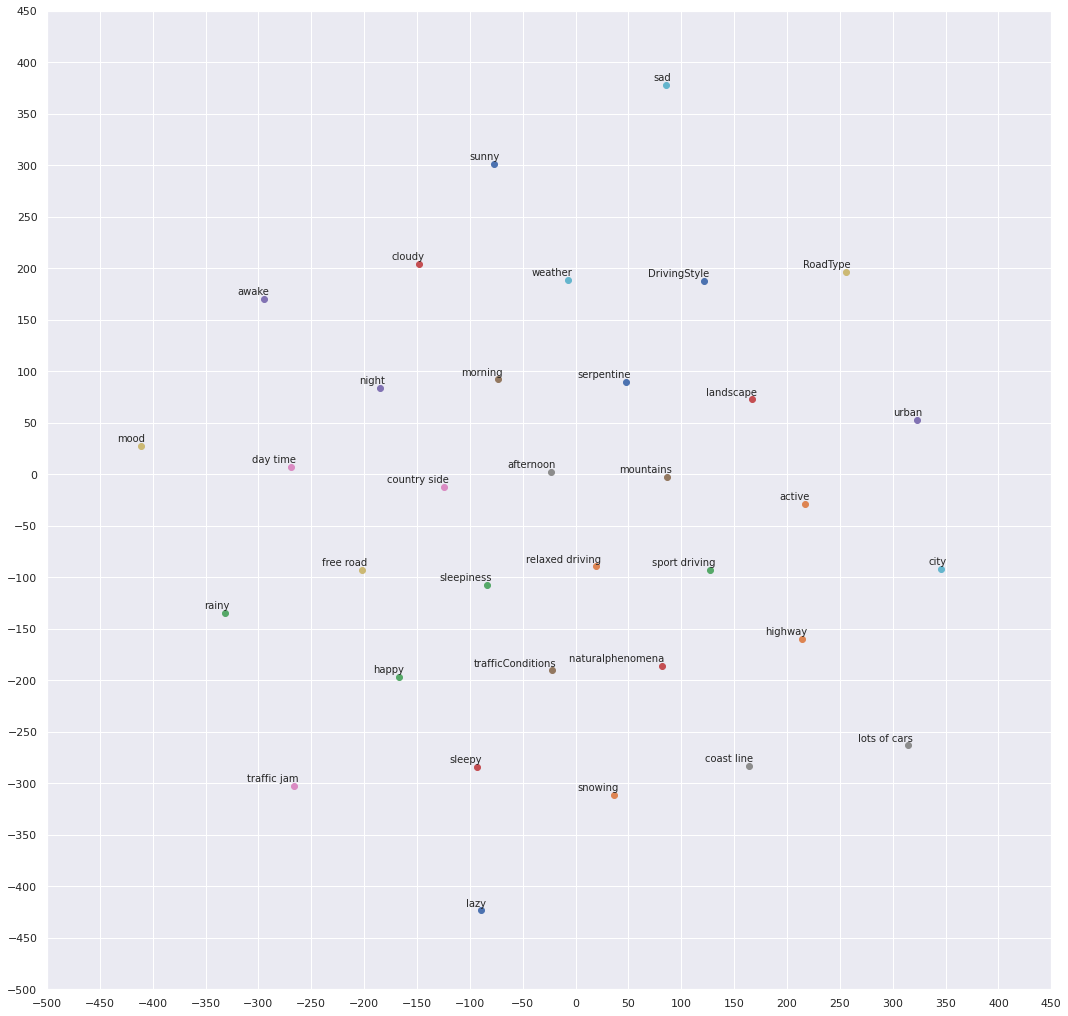

In [ ]:
#PLOT with cc.en.300
plot_w2v( wv2LowDim(words, ft), allWordsDF(df) )

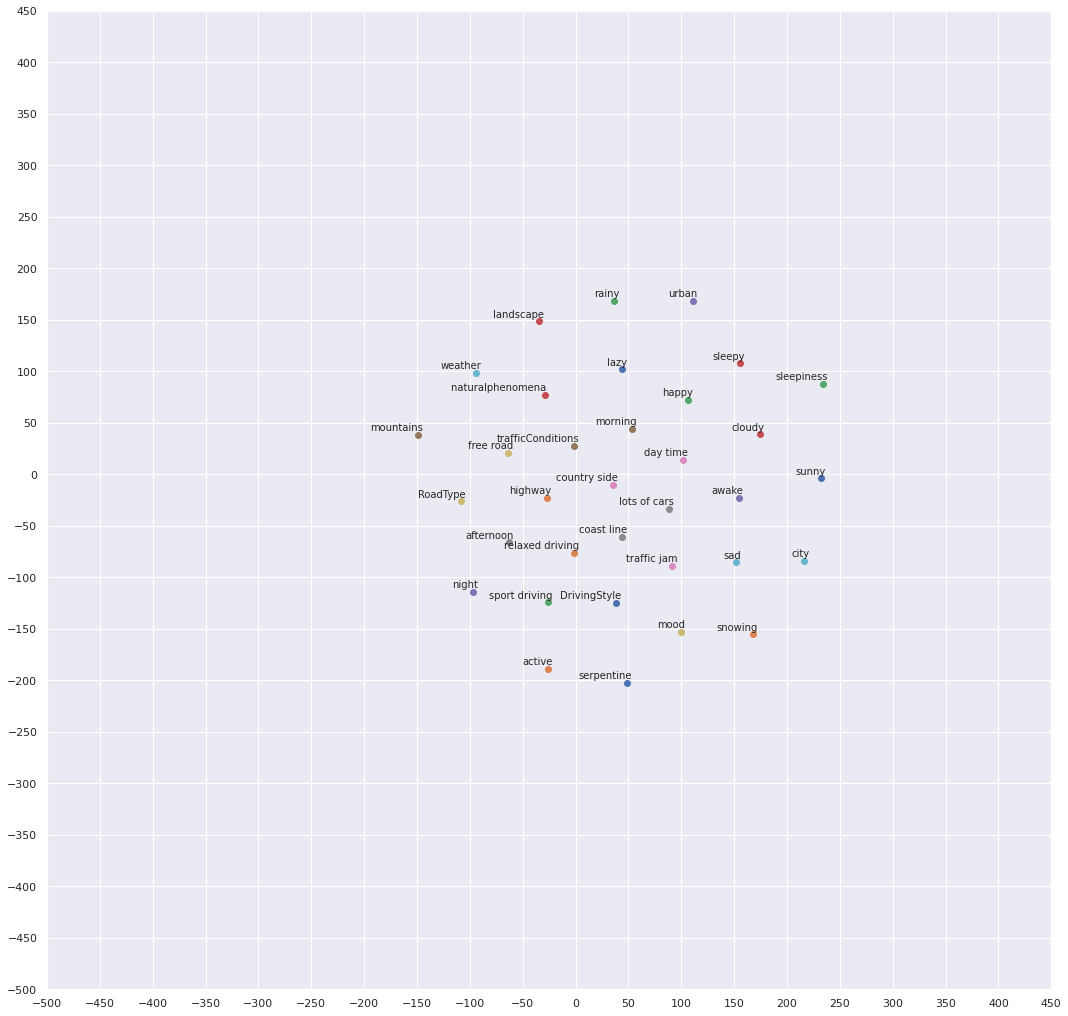

In [ ]:
#PLOT with wiki.en.zip
plot_w2v( wv2LowDim(allWordsDF(df,3), ft), allWordsDF(df,3) )

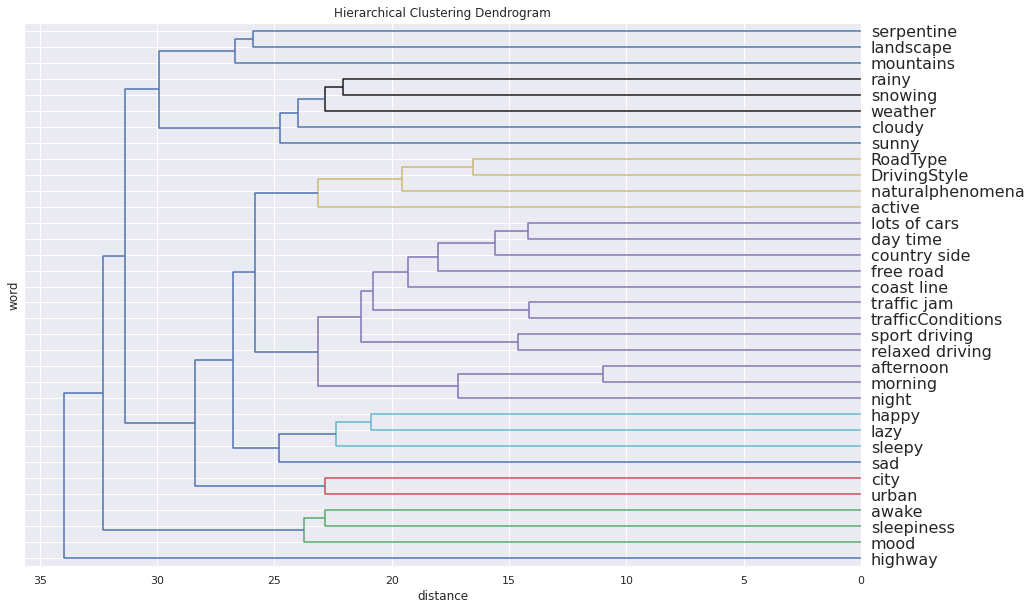

In [ ]:
#Dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

l = linkage(wordVec, method='complete', metric='seuclidean')

# calculate full dendrogram
plt.figure(figsize=(15, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('word')
plt.xlabel('distance')

dendrogram(
    l,
    #leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=16.,  # font size for the x axis labels
    orientation='left',
    leaf_label_func=lambda v: str(words[v])
)
plt.show()

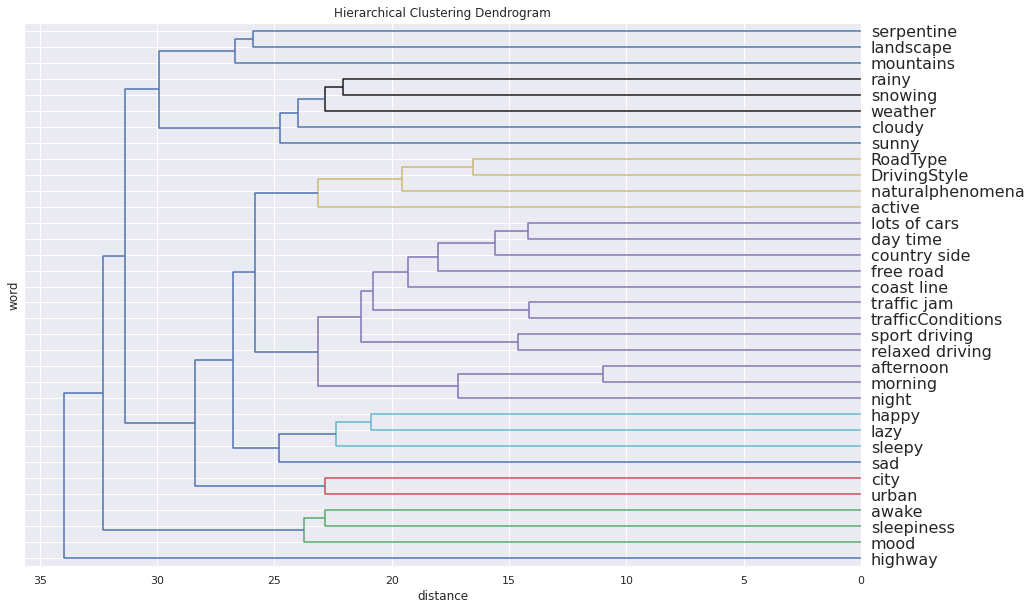

In [ ]:
#Dendogram #cc.en.300
from scipy.cluster.hierarchy import dendrogram, linkage

l = linkage(wordListVec(words), method='complete', metric='seuclidean')

# calculate full dendrogram
plt.figure(figsize=(15, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('word')
plt.xlabel('distance')

dendrogram(
    l,
    #leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=16.,  # font size for the x axis labels
    orientation='left',
    leaf_label_func=lambda v: str(words[v])
)
plt.show()

#Context Generalization


In [ ]:
# df = dfOri.copy()
df = context_generalization_ALLColumns(df)
df

,UserID,ItemID,Rating,DrivingStyle,sleepiness,RoadType_Level_1,trafficConditions_Level_1,landscape_Level_2,mood_Level_2,naturalphenomena _Level_2,weather_Level_2
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing rainy cloudy
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing rainy cloudy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


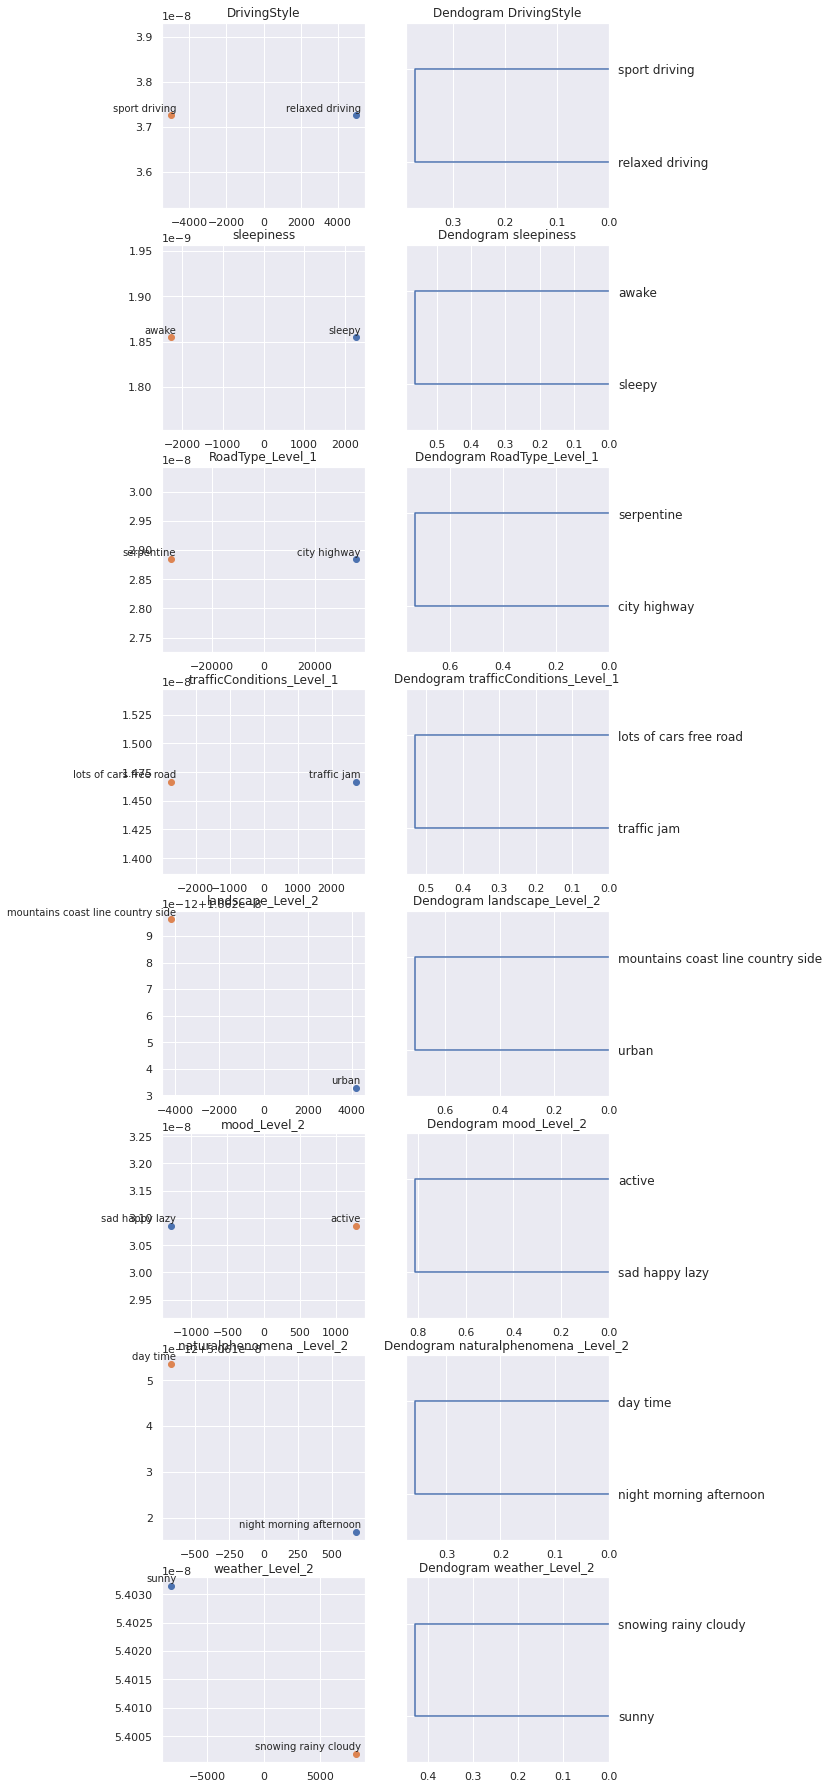

In [ ]:
# df = df.drop(columns=['DrivingStyle','sleepiness'])
# df = df.drop(columns=['RoadType_Level_1','trafficConditions_Level_1'])
plot_w2v_dendogram(df.columns[3:], ft, 4)

In [ ]:
# Verify the evolution of Sparsity of each Generalization Level
df = dfOri.copy()
print(sparsity(df))
print('Original              - %.5f %%' % (sparsity(df)*100))
for x in range(1,4):
  df = context_generalization_ALLColumns(df) #level_1
  print('Generalization Leve %d - %.5f %%' % (x, sparsity(df)*100))


0.9999268150073317
Orginal              - 99.99268 %
Generalization Leve 1 - 99.94852 %
Generalization Leve 2 - 99.74266 %
Generalization Leve 3 - 99.74266 %


# SEASONS PLOT

{'color_list': ['g', 'r', 'b'],
 'dcoord': [[0.0, 0.5457550243032478, 0.5457550243032478, 0.0],
  [0.0, 0.7932021054066203, 0.7932021054066203, 0.0],
  [0.5457550243032478,
   1.2212987110864648,
   1.2212987110864648,
   0.7932021054066203]],
 'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [10.0, 10.0, 30.0, 30.0]],
 'ivl': ['fall', 'winter', 'spring', 'summer'],
 'leaves': [2, 3, 0, 1]}

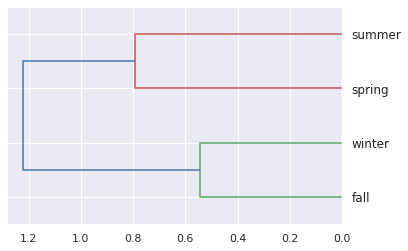

In [ ]:
uniqueWords = ['spring','summer', 'fall', 'winter']
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='cosine')
linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='cosine')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='euclidean')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='euclidean')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='seuclidean')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='seuclidean')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='correlation')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='correlation')

# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='centroid', metric='euclidean')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='ward', metric='euclidean')

# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='jaccard')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='jaccard')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='single', metric='hamming')
# linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='hamming')

dendrogram(
      linkage_dendogram,
      # ax=axs[axis_y,1],
      #leaf_rotation=90.,  # rotates the x axis labels
      # leaf_font_size=16.,  # font size for the x axis labels
      orientation='left',
      leaf_label_func=lambda v: str(uniqueWords[v])
    )



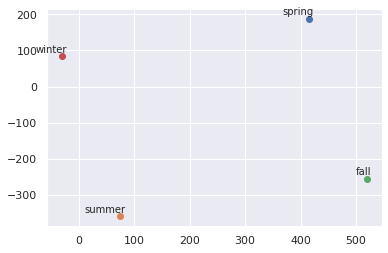

In [ ]:
low_dim_embs = wv2LowDim(uniqueWords, ft)
for i, label in enumerate(uniqueWords):
    x, y = low_dim_embs[i, :]
    plt.scatter(x, y)
    plt.annotate(label,
              xy=(x, y),
              xytext=(5, 2),
              textcoords='offset points',
              ha='right',
              va='bottom')

# WEEK DAYS - Word Vector Group

{'color_list': ['g', 'g', 'g', 'g', 'g', 'b'],
 'dcoord': [[0.0, 0.11218718535858252, 0.11218718535858252, 0.0],
  [0.0, 0.26652264560206806, 0.26652264560206806, 0.0],
  [0.0, 0.268668529230073, 0.268668529230073, 0.0],
  [0.26652264560206806,
   0.4801398585131881,
   0.4801398585131881,
   0.268668529230073],
  [0.11218718535858252,
   0.7015221784672333,
   0.7015221784672333,
   0.4801398585131881],
  [0.0, 1.2542745332175533, 1.2542745332175533, 0.7015221784672333]],
 'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [20.0, 20.0, 50.0, 50.0],
  [5.0, 5.0, 35.0, 35.0]],
 'ivl': ['tuesday',
  'wednesday',
  'thursday',
  'monday',
  'friday',
  'sunday',
  'saturday'],
 'leaves': [3, 4, 5, 2, 6, 0, 1]}

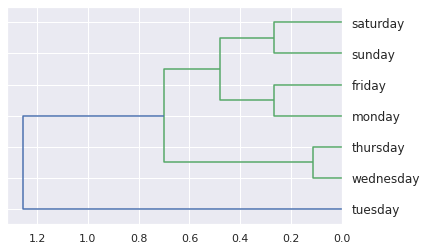

In [ ]:
uniqueWords = ['sunday','saturday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday']
linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='cosine')

dendrogram(
      linkage_dendogram,
      # ax=axs[axis_y,1],
      #leaf_rotation=90.,  # rotates the x axis labels
      # leaf_font_size=16.,  # font size for the x axis labels
      orientation='left',
      leaf_label_func=lambda v: str(uniqueWords[v])
    )

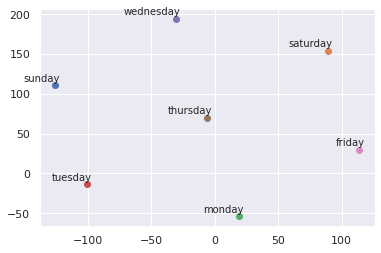

In [ ]:
low_dim_embs = wv2LowDim(uniqueWords, ft)
for i, label in enumerate(uniqueWords):
    x, y = low_dim_embs[i, :]
    plt.scatter(x, y)
    plt.annotate(label,
              xy=(x, y),
              xytext=(5, 2),
              textcoords='offset points',
              ha='right',
              va='bottom')

{'color_list': ['g', 'g', 'g', 'g', 'b'],
 'dcoord': [[0.0, 0.11218718535858252, 0.11218718535858252, 0.0],
  [0.0, 0.26652264560206806, 0.26652264560206806, 0.0],
  [0.0, 0.4075799098106758, 0.4075799098106758, 0.26652264560206806],
  [0.11218718535858252,
   0.7015221784672333,
   0.7015221784672333,
   0.4075799098106758],
  [0.0, 1.083509191022593, 1.083509191022593, 0.7015221784672333]],
 'icoord': [[15.0, 15.0, 25.0, 25.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [20.0, 20.0, 42.5, 42.5],
  [5.0, 5.0, 31.25, 31.25]],
 'ivl': ['tuesday',
  'wednesday',
  'thursday',
  'sunday saturday',
  'monday',
  'friday'],
 'leaves': [2, 3, 4, 0, 1, 5]}

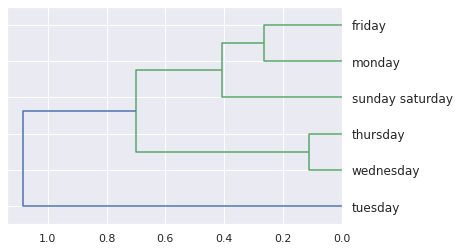

In [ ]:
uniqueWords = ['sunday saturday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday']
linkage_dendogram = linkage(wordListVec(uniqueWords, ft), method='complete', metric='cosine')

dendrogram(
      linkage_dendogram,
      # ax=axs[axis_y,1],
      #leaf_rotation=90.,  # rotates the x axis labels
      # leaf_font_size=16.,  # font size for the x axis labels
      orientation='left',
      leaf_label_func=lambda v: str(uniqueWords[v])
    )

# Sparsity for CARS
\[ SP =
  \]

In [ ]:
# Sparsity for original CARS matrix
df = dfOri.copy()
sparsity(df, print_details=1)

Cardinalities (Number of distinct values):
Users:             42
Items:             139
Ratings:           3938
Multi |Context|s:  9216
Overall Sparsity:  0.9999268150073317
Data Density:      7.318499266828482e-05
---------
nContexts: 8
Has Dimension UxI without Context:  True
---------


0.9999268150073317

In [ ]:
# Sparsity of just UxI (remove Context values)
df_RS = collect_just_UserItemMatrix(df,3)
sparsity(df_RS, print_details=1)

Cardinalities (Number of distinct values):
Users:             42
Items:             139
Ratings:           1914
Multi |Context|s:  NA
Overall Sparsity:  0.6721479958890031
Data Density:      0.3278520041109969
---------
nContexts: 0
Has Dimension UxI without Context:  True
---------


0.6721479958890031

#SPARSITY all Columns + Group Titles


In [ ]:
# Sparsity
df = dfOri.copy()
print('Original              - %.5f %%' % (sparsity(df)*100))
for x in range(1,4):
  df = context_generalization_ALLColumns(df, use_same_column=1)
  print('Generalization Level %d - %.5f %%' % (x, sparsity(df)*100))

qtd_context_variables = len(df.iloc[:,3:].columns)
for y in range(1,qtd_context_variables):
  df = context_generalization_group_columns(df, drop_original_columns=1)
  print('Generalization Columns - %.5f %%' % ( sparsity(df.drop_duplicates())*100))

Original              - 99.99268 %
Generalization Level 1 - 99.94852 %
Generalization Level 2 - 99.74266 %
Generalization Level 3 - 99.74266 %
Generalization Columns - 99.74266 %
Generalization Columns - 99.74266 %
Generalization Columns - 99.74266 %
Generalization Columns - 99.48732 %
Generalization Columns - 99.31819 %
Generalization Columns - 97.71946 %
Generalization Columns - 96.10967 %


In [ ]:
# DF all grouped.
df

,UserID,ItemID,Rating,landscape mood sleepiness trafficConditions weather RoadType DrivingStyle naturalphenomena
0,1001,715,2,sunny
1,1001,267,4,sunny
2,1001,294,2,sunny
3,1001,259,4,snowing rainy cloudy
4,1001,674,2,snowing rainy cloudy
...,...,...,...,...
4007,1042,716,1,NaN
4008,1042,733,1,NaN
4009,1042,682,1,NaN
4010,1042,691,1,NaN


#CARSkit - Verify input CSV

https://arxiv.org/pdf/1511.03780.pdf

Special Notes: If you do have missing values in the context conditions, just leave
it as empty entries, or simply set “na” (NA, Not Available) as the value of the context
conditions. This setting is useful for two scenarios – either you have missing values in
context conditions, or you blend ratings with & without considering contexts.

In [ ]:
df = dfOri.copy()

%cd {DATASETS_FOLDER}
df.to_csv(DATASETS_FOLDER + 'InCarMusic.csv', index=False)
!head -4 InCarMusic.csv

/content/drive/My Drive/CARS/Datasets
UserID,ItemID, Rating,DrivingStyle,landscape,mood,naturalphenomena ,RoadType,sleepiness,trafficConditions,weather
1001,715,2,,,,,,,,sunny
1001,267,4,,,,,,,,sunny
1001,294,2,,,,,,,,sunny


In [ ]:
!java -jar /content/CARSKit/jar/CARSKit-v0.3.5.jar -c /content/drive/My\ Drive/CARS/Datasets/setting.conf

[INFO ] 2020-06-03 13:58:36,857 -- WorkingPath: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace/
[INFO ] 2020-06-03 13:58:36,866 -- Your original rating data path: /content/drive/My Drive/CARS/Datasets/InCarMusic.csv
[INFO ] 2020-06-03 13:58:36,866 -- Current working path: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace/
[WARN ] 2020-06-03 13:58:36,872 -- You rating data is in Compact format. CARSKit is working on transformation on the data format...
[INFO ] 2020-06-03 13:58:36,982 -- User, Item, Rating, drivingstyle:na, drivingstyle:relaxed driving, drivingstyle:sport driving, landscape:na, landscape:urban, landscape:mountains, landscape:country side, landscape:coast line, mood:na, mood:sad, mood:lazy, mood:active, mood:happy, naturalphenomena:na, naturalphenomena:night, naturalphenomena:morning, naturalphenomena:day time, naturalphenomena:afternoon, roadtype:na, roadtype:city, roadtype:serpentine, roadtype:highway, sleepiness:na, sleepiness:sleepy, sleepiness:awake, t

In [ ]:
%cd {DATASETS_FOLDER}
dfNA=df.fillna('na')
dfNA.to_csv(DATASETS_FOLDER + 'InCarMusic.csv', index=False)
!head -4 InCarMusic.csv

/content/drive/My Drive/CARS/Datasets
UserID,ItemID, Rating,DrivingStyle,landscape,mood,naturalphenomena ,RoadType,sleepiness,trafficConditions,weather
1001,715,2,na,na,na,na,na,na,na,sunny
1001,267,4,na,na,na,na,na,na,na,sunny
1001,294,2,na,na,na,na,na,na,na,sunny


In [ ]:
!java -jar /content/CARSKit/jar/CARSKit-v0.3.5.jar -c /content/drive/My\ Drive/CARS/Datasets/setting.conf

[INFO ] 2020-06-03 13:58:56,645 -- WorkingPath: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace/
[INFO ] 2020-06-03 13:58:56,653 -- Your original rating data path: /content/drive/My Drive/CARS/Datasets/InCarMusic.csv
[INFO ] 2020-06-03 13:58:56,653 -- Current working path: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace/
[WARN ] 2020-06-03 13:58:56,661 -- You rating data is in Compact format. CARSKit is working on transformation on the data format...
[INFO ] 2020-06-03 13:58:56,748 -- User, Item, Rating, drivingstyle:na, drivingstyle:relaxed driving, drivingstyle:sport driving, landscape:na, landscape:urban, landscape:mountains, landscape:country side, landscape:coast line, mood:na, mood:sad, mood:lazy, mood:active, mood:happy, naturalphenomena:na, naturalphenomena:night, naturalphenomena:morning, naturalphenomena:day time, naturalphenomena:afternoon, roadtype:na, roadtype:city, roadtype:serpentine, roadtype:highway, sleepiness:na, sleepiness:sleepy, sleepiness:awake, t

#CARSkit

In [ ]:
# Evaluation Original
df = dfOri.copy()
CARSKIT(df)

In [ ]:
# Generalization Level-1
df = context_generalization_ALLColumns(df)
CARSKIT(df)

In [ ]:
CARSKit_test_kfold(df)

(0.713789, 1.008715)

In [ ]:
# Generalization Level-2
# df = context_generalization_ALLColumns(df)
CARSKit_test_Generalization(df)

In [ ]:
CARSKit_test(df)

(0.664443, 0.946721)

#SEGMENTs


In [ ]:
# df[ ~df.mood.isna()]
df[ ~df.mood.isna()].groupby('mood').nunique()
# df[ df.mood == 'lazy'].groupby(' Rating').nunique()
# df.groupby(' Rating').nunique()

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
mood,,,,,,,,,,,
active,30,79,6,0,0,1,0,0,0,0,0
happy,28,72,6,0,0,1,0,0,0,0,0
lazy,33,73,6,0,0,1,0,0,0,0,0
sad,24,71,6,0,0,1,0,0,0,0,0


In [ ]:
df

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# MAE/RMSE for each VARIABLE

In [ ]:
df = dfOri.copy()
df_R, df_generalized_CONDITIONS = collect_metrics_CARSKit_Generalization(df)
# df_R.to_excel(DATASETS_FOLDER + 'CARSKit-Level0-1-MAE-DBPEDIA.xlsx')

Generalized Conditions:  landscape-urban.country side
0.707257 0.992605
Generalized Conditions:  landscape-urban country side.mountains
0.70594 0.990581
Generalized Conditions:  mood-lazy.happy
0.711152 1.003451
Generalized Conditions:  mood-lazy happy.active
0.712958 1.008829
Generalized Conditions:  naturalphenomena -day time.afternoon
0.723552 1.01709
Generalized Conditions:  naturalphenomena -night.morning
0.720652 1.020852
Generalized Conditions:  RoadType-serpentine.highway
0.701861 0.986852
Generalized Conditions:  trafficConditions-traffic jam.free road
0.709813 1.003783
Generalized Conditions:  weather-snowing.cloudy
0.698781 0.988216
Generalized Conditions:  weather-sunny.rainy
0.70883 1.002859
Generalized Conditions:  landscape-urban.country side;mood-lazy.happy
0.697723 0.987179
Generalized Conditions:  landscape-urban country side.mountains;mood-lazy happy.active
0.707126 1.002636
Generalized Conditions:  landscape-urban.country side;naturalphenomena -day time.afternoon
0.

ValueError: ignored

In [ ]:
df_generalized_CONDITIONS

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,natural phenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny rainy
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny rainy
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny rainy
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing cloudy
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def plot_generalization_results(y, x, x_ori, title='', y_ticks='' ):
  plt.plot(y, x, label='Generalized')

  if x_ori != 0:
    plt.plot(y, [x_ori for i in range(len(x))], '--', color='darkorange', label='Original' )

  plt.plot(y, [min(x) for i in range(len(x))], 'g--' , label='Max/Min')
  plt.plot(y, [max(x) for i in range(len(x))], 'g--' )
  plt.title(title, fontsize=20)
  plt.xlabel('Generalized Values', fontsize=12)
  plt.legend(loc='upper right', fontsize=12)
  if len(y_ticks) == len(y):
    plt.xticks(y, y_ticks, rotation=90)


<function matplotlib.pyplot.show>

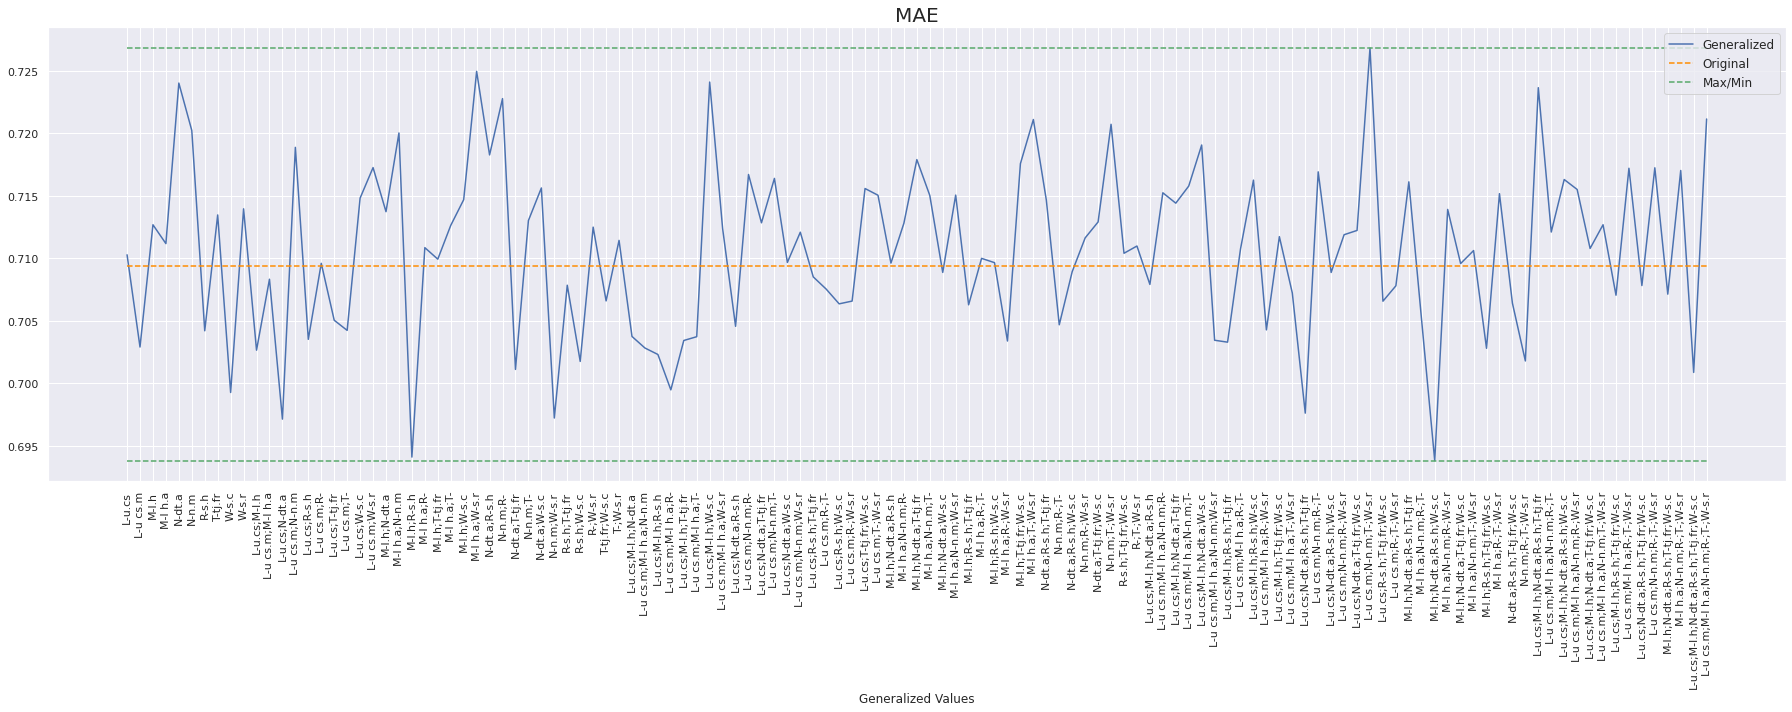

In [ ]:
MAE_Original = float(df_R[ df_R['Generalized Conditions'] == 'ORIGINAL']['MAE'])
RMSE_Original = float(df_R[ df_R['Generalized Conditions'] == 'ORIGINAL']['RMSE'])
df_R1 = df_R[ ~(df_R['Generalized Conditions'] == 'ORIGINAL') ] # Take out ORIGINAL

Y_MAE = df_R1.MAE.to_list()
Y_RMSE = df_R1.RMSE.to_list()
X = range(len(Y_MAE))

X_ticks_full = df_R1['Generalized Conditions'].to_list()
#Change for just Initials
dict_titles_initial = create_dict_for_initial_of_values(df)
X_ticks_INITIALS = replace_names_for_initials_LST(dict_titles_initial, X_ticks_full )

fig = plt.figure(figsize=(25,10))
plot_generalization_results(X, Y_MAE, MAE_Original, title='MAE', y_ticks=X_ticks_INITIALS )
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show>

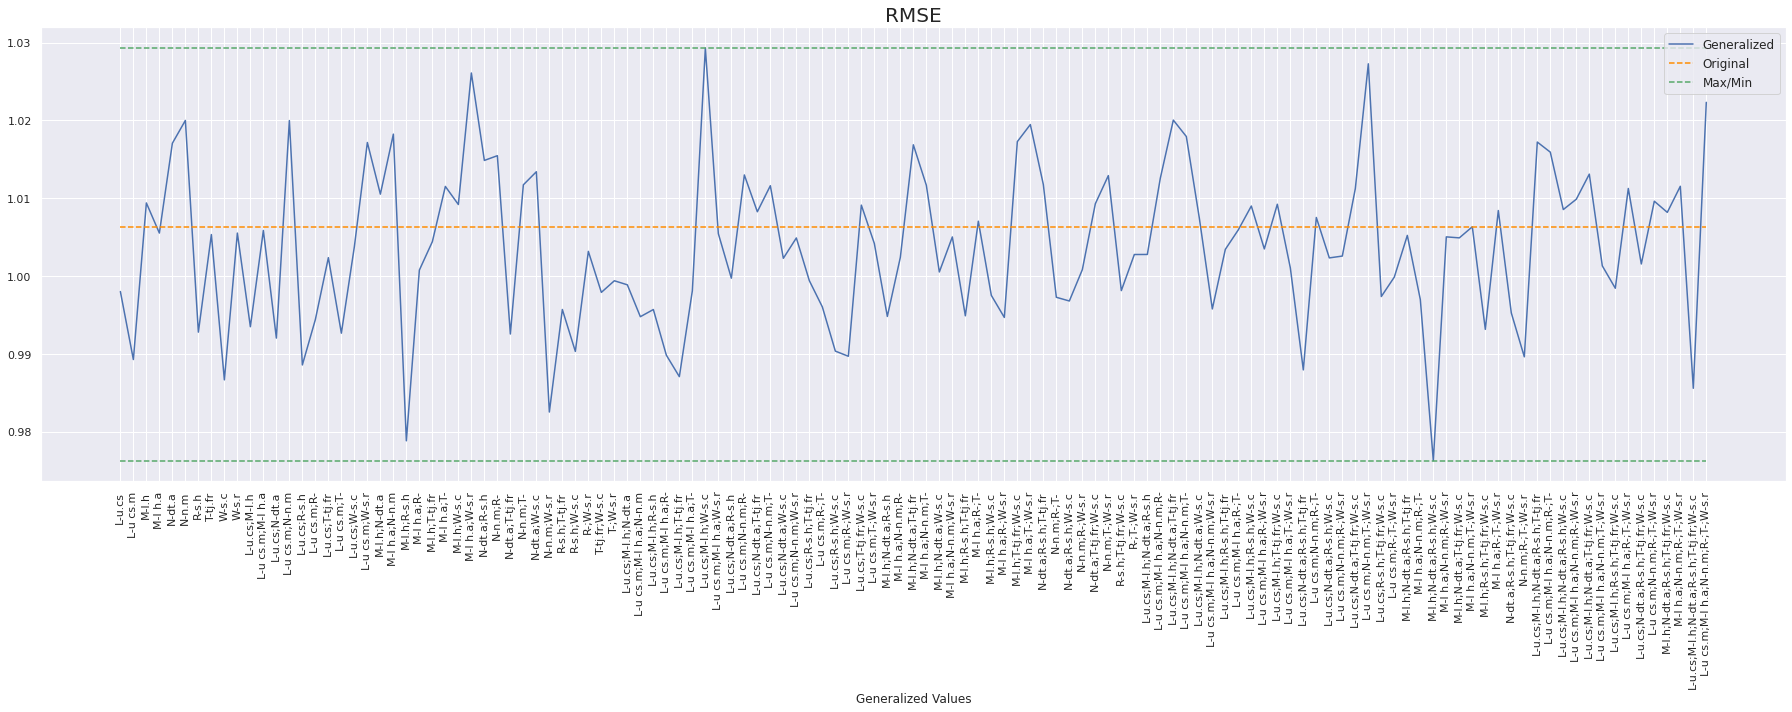

In [ ]:
fig = plt.figure(figsize=(25,10))
plot_generalization_results(X, Y_RMSE, RMSE_Original, title='RMSE', y_ticks=X_ticks_INITIALS )
plt.tight_layout()
plt.show

In [ ]:
# Rename Column to obtain an Word Vector:
df_generalized_CONDITIONS.rename(columns={"naturalphenomena ": "natural phenomena", "sleepiness": "sleep"}, inplace=True)
df_R_T, df_generalized_COND_FACTORS = collect_metrics_CARSKit_Generalization_TITLES(df_generalized_CONDITIONS)

In [ ]:
#PLOT GROUPING TITLES

#Collect from First Conditions test;
MAE_Original = float(df_R[ df_R['Generalized Conditions'] == 'ORIGINAL']['MAE'])
RMSE_Original = float(df_R[ df_R['Generalized Conditions'] == 'ORIGINAL']['RMSE'])

df_R1T = df_R_T[ ~(df_R['Generalized Conditions'] == 'ORIGINAL') ] # Take out ORIGINAL

Y_MAE = df_R1T.MAE.to_list()
Y_RMSE = df_R1T.RMSE.to_list()
X = range(len(Y_MAE))

X_ticks_full = df_R1T['Generalized Conditions'].to_list()
#Change for just Initials
dict_titles_initial = create_dict_for_initial_of_values(df_generalized_CONDITIONS)
X_ticks_INITIALS = replace_names_for_initials_LST(dict_titles_initial, X_ticks_full )


<function matplotlib.pyplot.show>

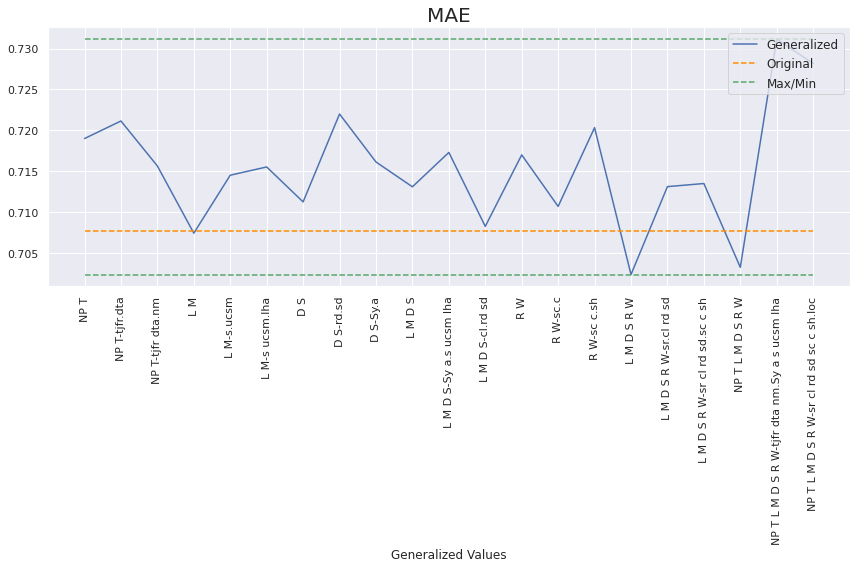

In [ ]:
fig = plt.figure(figsize=(12,8))
plot_generalization_results(X, Y_MAE, MAE_Original, title='MAE', y_ticks=X_ticks_INITIALS )
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show>

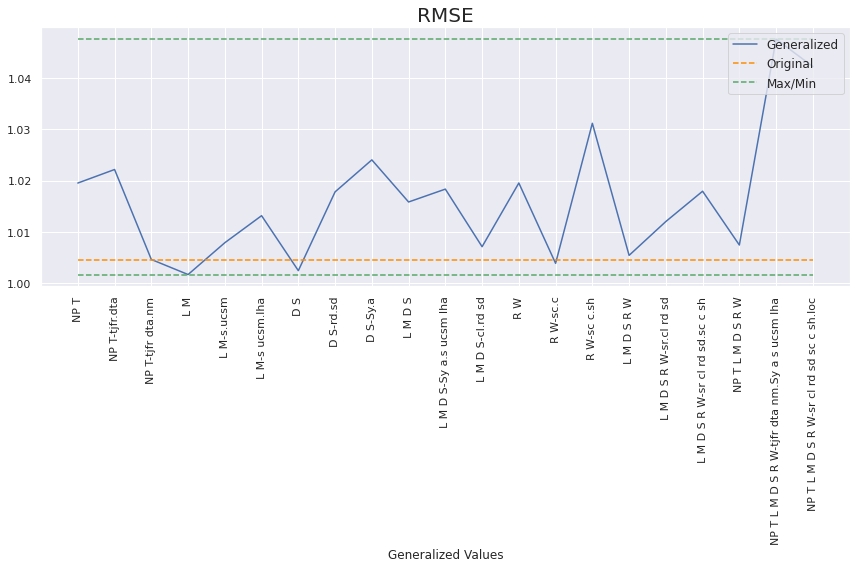

In [ ]:
fig = plt.figure(figsize=(12,8))
plot_generalization_results(X, Y_RMSE, RMSE_Original, title='RMSE', y_ticks=X_ticks_INITIALS )
plt.tight_layout()
plt.show

In [ ]:
df_R_T

,Generalized Conditions,SPARSITY,MAE,RMSE
0,ORIGINAL,0.997421,0.724339,1.024002
1,natural phenomena trafficConditions,0.997421,0.718986,1.019518
2,natural phenomena trafficConditions-traffic ja...,0.996589,0.721134,1.022158
3,natural phenomena trafficConditions-traffic ja...,0.994942,0.715630,1.004612
4,landscape mood,0.994942,0.707405,1.001675
5,landscape mood-sad.urban country side mountains,0.993311,0.714500,1.007881
6,landscape mood-sad urban country side mountain...,0.990155,0.715509,1.013153
7,DrivingStyle sleep,0.990155,0.711233,1.002430
8,DrivingStyle sleep-relaxed driving.sport driving,0.986982,0.721990,1.017798
9,DrivingStyle sleep-sleepy.awake,0.980696,0.716119,1.024040


In [ ]:
def replace_names_for_initials_LST(dict_titles_initial, lst_values):
  #Create Initials list for use in PLOTs;
  lst_corr_col_I = []
  for corr_col in lst_values:
    corr_col = corr_col.replace('NoMoreAggregation', '')
    for title, initial in dict_titles_initial.items():
      corr_col = corr_col.replace(title, initial)

    lst_corr_col_I.append(corr_col)
  return lst_corr_col_I

In [ ]:
def context_generalization_column(df_p, column, drop_original_column=1, model=ft, use_same_column=0):
  uniqueWords = uniqueValuesOfColumn(df_p[column])
  if len(uniqueWords) <= 2:  #If there is just 1 value, don't do nothing and return the same DF.
    return df_p, column+'-NoMoreAggregation'

  linkage_dendogram = linkage(wordListVec(uniqueWords, model), method=LINKAGE_METHOD, metric=LINKAGE_METRIC)
  wordPoint_1 = uniqueWords[int(linkage_dendogram[0][0])]
  wordPoint_2 = uniqueWords[int(linkage_dendogram[0][1])]

  titleColumn, level_number = collect_titleColumn_level(column)

  if use_same_column == 1:
    df_p[column] = df_p[column].apply(lambda x: wordPoint_1 + ' ' + wordPoint_2 if (x==wordPoint_1 or x==wordPoint_2) else x)

  else:
    df_p[titleColumn +'_Level_'+ level_number] = df_p[column].apply(lambda x: wordPoint_1 + ' ' + wordPoint_2 if (x==wordPoint_1 or x==wordPoint_2) else x)

    if drop_original_column == 1:
      df_p = df_p.drop(columns=[column])

  conditions_aggregate = (titleColumn + '-' + wordPoint_1 + '.' + wordPoint_2)
  return (df_p, conditions_aggregate)

In [ ]:
def context_generalization_ListColumns(df_p, list_column, model=ft):
  lst_name_column_conditions = []
  for column in list_column:
    df_p, name_column_conditions = context_generalization_column(df_p, column, use_same_column=1)
    lst_name_column_conditions.append(name_column_conditions)
  return df_p, ';'.join(lst_name_column_conditions)

In [ ]:
def bigger_count_unique_conditions(dfp, lst_columns):
  bigger_num_unique_conditions = 0
  for column_name in lst_columns:
    num_unique_conditions = len( dfp[column_name][ dfp[column_name].notna() ].unique() )
    if num_unique_conditions > bigger_num_unique_conditions:
      bigger_num_unique_conditions = num_unique_conditions
  return bigger_num_unique_conditions

In [ ]:
def filter_columns_with_more_N_conditions(dfp, Number_Conditions=2):
  # collect just columns names which has more than 2 Conditions.
  lst_columns = []
  for column_name in dfp.columns[3:]:
    if len( dfp[column_name][ dfp[column_name].notna() ].unique() ) > 2:
      lst_columns.append(column_name)
  return lst_columns

In [ ]:
def collect_metrics_CARSKit_Generalization(df_p):
  #Level 0 (Basic - No Generalization)
  mae, rmse = CARSKit_test_kfold(df_p)
  sparsity_value = sparsity(df_p)
  df_CARSKit_Result = pd.DataFrame([['ORIGINAL', sparsity_value, mae, rmse]], columns = ['Generalized Conditions','SPARSITY', 'MAE', 'RMSE'])

  # list_columns = df_p.columns[3:]
  list_columns = filter_columns_with_more_N_conditions(df_p, Number_Conditions=2)
  for L in range(1, len(list_columns)+1):
      for subset in itertools.combinations(list_columns, L):
        df_generalized = df_p.copy()
        n_unique_conditions = bigger_count_unique_conditions(df_generalized, subset)
        while n_unique_conditions > 2:
          df_generalized, name_generalized_conditions = context_generalization_ListColumns(df_generalized, subset)
          mae, rmse = CARSKit_test_kfold(df_generalized)
          sparsity_value = sparsity(df_generalized)
          print('Generalized Conditions: ', name_generalized_conditions)
          print(mae, rmse)
          a_series = pd.Series([str(name_generalized_conditions), sparsity_value, mae, rmse], index = df_CARSKit_Result.columns)
          df_CARSKit_Result =  df_CARSKit_Result.append(a_series, ignore_index=True)
          n_unique_conditions = bigger_count_unique_conditions(df_generalized, subset)
        if len(subset) == len(list_columns):
          df_generalized_complete = df_generalized.copy()

  return df_CARSKit_Result, df_generalized_complete

def collect_metrics_CARSKit_Generalization_TITLES(df_p):
  #Level 0 (Basic - No Generalization)
  mae, rmse = CARSKit_test_kfold(df_p)
  sparsity_value = sparsity(df_p)
  df_CARSKit_Result = pd.DataFrame([['ORIGINAL', sparsity_value, mae, rmse]], columns = ['Generalized Conditions','SPARSITY', 'MAE', 'RMSE'])

  df_generalized = df_p.copy()
  qtd_context_variables = len(df_p.iloc[:,3:].columns)
  for generalization_level_title in range(1,qtd_context_variables):
    df_generalized, name_generalized_Factors = context_generalization_group_columns(df_generalized, drop_original_columns=1)
    mae, rmse = CARSKit_test_kfold(df_generalized)
    sparsity_value = sparsity(df_generalized)
    print('Generalized Factors: ', name_generalized_Factors)
    print(mae, rmse)
    a_series = pd.Series([str(name_generalized_Factors), sparsity_value, mae, rmse], index = df_CARSKit_Result.columns)
    df_CARSKit_Result =  df_CARSKit_Result.append(a_series, ignore_index=True)

    for _ in range(2):
      df_generalized, name_generalized_conditions = context_generalization_ListColumns(df_generalized, [name_generalized_Factors])
      mae, rmse = CARSKit_test_kfold(df_generalized)
      sparsity_value = sparsity(df_generalized)
      print('Generalized Conditions: ', name_generalized_conditions)
      print(mae, rmse)
      a_series = pd.Series([str(name_generalized_conditions), sparsity_value, mae, rmse], index = df_CARSKit_Result.columns)
      df_CARSKit_Result =  df_CARSKit_Result.append(a_series, ignore_index=True)

  return df_CARSKit_Result, df_generalized

In [ ]:
def context_generalization_group_columns(df_p, drop_original_columns=1, model=ft):
  uniqueWords = df_p.columns[3:]
  uniqueWords_Formated = split_Upper_Letters( uniqueWords )
  linkage_dendogram = linkage(wordListVec(uniqueWords_Formated, model), method=LINKAGE_METHOD, metric=LINKAGE_METRIC)
  column1 = uniqueWords[int(linkage_dendogram[0][0])]
  column2 = uniqueWords[int(linkage_dendogram[0][1])]
  # print(column1, column2 )

  df_p = generalize_group_2_columns(df_p, column1, column2, drop_original_columns=drop_original_columns)
  return df_p, column1 + ' ' + column2

def split_Upper_Letters(lst_words):
  lst_result = []
  for w in lst_words:
    lst_result.append( ' '.join( re.findall('[a-zA-Z][^A-Z]*', w) ).lower() )

  return lst_result

#MAE/RMSE with Title Generalize

In [ ]:
df = dfOri.copy()
df_R=collect_metrics_CARSKit_Generalization(df, number_levels_generalization=2)
df_R.to_excel(DATASETS_FOLDER + 'CARSKit-Level0-1-MAE-DBPEDIA.xlsx')

In [ ]:
# Sparsity
df = dfOri.copy()
print('Original              - %.5f %%' % (sparsity(df)*100))
for x in range(1,4):
  df = context_generalization_ALLColumns(df, use_same_column=1)
  print('Generalization Level %d - %.5f %%' % (x, sparsity(df)*100))

qtd_context_variables = len(df.iloc[:,3:].columns)
for y in range(1,qtd_context_variables):
  df = context_generalization_group_columns(df, drop_original_columns=1)
  print('Generalization Columns - %.5f %%' % ( sparsity(df.drop_duplicates())*100))

In [ ]:
def collect_metrics_CARSKit_Generalization(df_p, number_levels_generalization=1, group_title=0):
  #Level 0 (Basic - No Generalization)
  mae, rmse = CARSKit_test(df_p)
  df_CARSKit_Result = pd.DataFrame([[0, ' ', mae, rmse]], columns = ["Level", "Variables", 'MAE', 'RMSE'])

  list_columns = df_p.columns[3:]
  for L in range(1, len(list_columns)+1):
      for subset in itertools.combinations(list_columns, L):
        df_generalized = df_p.copy()
        for generalization_level in range(1,number_levels_generalization+1):
          df_generalized = context_generalization_ListColumns(df_generalized, subset)
          mae, rmse = CARSKit_test(df_generalized)
          print('Level: ', generalization_level, ' Var: ', subset,  ' MAE: ', mae)
          a_series = pd.Series([generalization_level, str(subset), mae, rmse], index = df_CARSKit_Result.columns)
          df_CARSKit_Result =  df_CARSKit_Result.append(a_series, ignore_index=True)

  if group_title=1:
    qtd_context_variables = len(df_generalized.iloc[:,3:].columns)
    for generalization_level_title in range(1,qtd_context_variables):
      df_generalized = context_generalization_group_columns(df_generalized, drop_original_columns=1)
      mae, rmse = CARSKit_test(df_generalized)
      print('Level: ', generalization_level, ' Var: ', subset,  ' MAE: ', mae)
      a_series = pd.Series([generalization_level_title, str(subset), mae, rmse], index = df_CARSKit_Result.columns)
      df_CARSKit_Result =  df_CARSKit_Result.append(a_series, ignore_index=True)

  return df_CARSKit_Result

SyntaxError: ignored

In [ ]:
df_generalized = df.copy()
df_generalized = context_generalization_group_columns(df_generalized.columns[3:], drop_original_columns=1)
df_generalized

In [ ]:
df_generalized

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#GPT2 - Transformers Word Vector

In [ ]:
! pip install pytorch-pretrained-bert
! pip install spacy ftfy==4.4.3
! python -m spacy download en

In [ ]:
import torch
from pytorch_pretrained_bert import GPT2Tokenizer, GPT2Model, GPT2LMHeadModel

import argparse
import logging
from tqdm import trange

import torch
import torch.nn.functional as F
import numpy as np

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

In [ ]:
text_index = tokenizer.encode('mountain')
vector = model.transformer.wte.weight[text_index,:]

# Graph SEGMENT


In [ ]:
import networkx as nx

In [ ]:
def transform_context_in_graph_element(dfp, colName):
  df_append = pd.DataFrame()
  df_append2 = pd.DataFrame()
  df_append['Source'] = 'U-' + dfp[dfp[colName].notna() ]['UserID'].astype(str)
  df_append['Target'] = '' + colName + ' ' + dfp[dfp[colName].notna() ][colName].astype(str)
  df_append['Rating'] = dfp[dfp[colName].notna() ][' Rating'].astype(str)

  df_append2['Source'] = 'I-' + dfp[dfp[colName].notna() ]['ItemID'].astype(str)
  df_append2['Target'] = '' + colName + ' ' + dfp[dfp[colName].notna() ][colName].astype(str)
  df_append2['Rating'] = dfp[dfp[colName].notna() ][' Rating'].astype(str)

  return df_append.append(df_append2)

def plot_degree_rank(G):
  degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
  (largest_hub, degree) = sorted([ (n,d) for n, d in G.degree()], reverse=True)[0]
  print('Node with high Degree: ', largest_hub)
  print('Degree:', degree)
  dmax = max(degree_sequence)

  plt.loglog(degree_sequence, 'b-', marker='o')
  plt.title("Degree rank plot")
  plt.ylabel("degree")
  plt.xlabel("rank")

  # draw graph in inset
  # plt.axes([0.45, 0.45, 0.45, 0.45])
  # Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
  # pos = nx.spring_layout(Gcc)
  # plt.axis('off')
  # nx.draw_networkx_nodes(Gcc, pos, node_size=20)
  # nx.draw_networkx_edges(Gcc, pos, alpha=0.4)

  plt.show()

# Filter Original DF and verify Sparsity:
def filter_df_based_on_subGraph(dfp, nb):
  list_users = []
  list_items = []
  for i in nb:
    if len(i.split('-')) == 2:
      (ui, value)=i.split('-')
      if ui == 'U':
        list_users.append(value)
      if ui == 'I':
        list_items.append(value)
    # print(ui, value)

  return dfp[ dfp['UserID'].isin(list_users) |  dfp['ItemID'].isin(list_items)  ].drop_duplicates()

def node_high_degree(G):
  (largest_hub, degree) = sorted([ (n,d) for n, d in G.degree()], reverse=True)[0]
  return largest_hub, degree

In [ ]:
df_graph = pd.DataFrame()
df_graph['Source'] = 'U-'+df['UserID'].astype(str)
df_graph['Target'] = 'I-'+df['ItemID'].astype(str)
df_graph['Rating'] = df[' Rating'].astype(str)

for colTitle in df.columns[3:]:
  df_graph = df_graph.append( transform_context_in_graph_element(df, colTitle), ignore_index=True )

df_graph = df_graph.drop_duplicates().reset_index()

df_graph

,index,Source,Target,Rating
0,0,U-1001,I-715,2
1,1,U-1001,I-267,4
2,2,U-1001,I-294,2
3,3,U-1001,I-259,4
4,4,U-1001,I-674,2
...,...,...,...,...
6172,10024,I-725,weather snowing,1
6173,10025,I-278,weather rainy,1
6174,10026,I-723,weather sunny,1
6175,10027,I-682,weather sunny,1


In [ ]:
G = nx.from_pandas_edgelist(df=df_graph, source='Source', target='Target', edge_attr='Rating')

# G.add_nodes_from(nodes_for_adding=df_graph.ID.tolist())

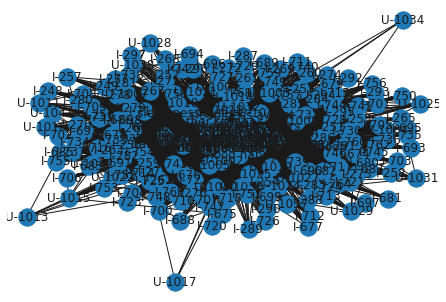

In [ ]:
 # Plot all Nodes (U x I x Contexts)
 nx.draw(G, with_labels=True)

In [ ]:
# Higher degree node:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
degree_nodes = sorted([n for n, d in G.degree()], reverse=True)
print(degree_sequence[:10])
print(degree_nodes[:10])

[165, 142, 129, 128, 125, 123, 122, 120, 118, 116]
['weather sunny', 'weather snowing', 'weather rainy', 'weather cloudy', 'trafficConditions traffic jam', 'trafficConditions lots of cars', 'trafficConditions free road', 'sleepiness sleepy', 'sleepiness awake', 'naturalphenomena  night']


In [ ]:
G.degree()

DegreeView({'U-1001': 29, 'I-715': 23, 'I-267': 24, 'I-294': 24, 'I-259': 28, 'I-674': 21, 'I-285': 28, 'I-279': 26, 'I-754': 27, 'I-694': 16, 'I-251': 28, 'U-1002': 54, 'I-250': 29, 'I-702': 18, 'I-714': 22, 'I-762': 21, 'I-275': 19, 'I-295': 28, 'I-757': 26, 'I-727': 20, 'I-256': 23, 'I-726': 14, 'I-730': 25, 'I-718': 23, 'I-745': 22, 'I-263': 27, 'I-732': 29, 'I-683': 22, 'I-751': 24, 'I-719': 25, 'I-716': 25, 'I-737': 20, 'I-273': 29, 'I-676': 29, 'I-760': 24, 'I-748': 22, 'I-744': 19, 'I-743': 31, 'I-690': 26, 'U-1003': 34, 'I-736': 21, 'I-269': 18, 'I-296': 19, 'I-711': 20, 'I-741': 23, 'I-759': 21, 'I-257': 14, 'I-739': 27, 'I-271': 21, 'U-1004': 17, 'I-266': 25, 'I-735': 17, 'I-701': 21, 'U-1005': 46, 'I-747': 21, 'I-264': 17, 'I-700': 19, 'I-721': 22, 'I-708': 17, 'I-758': 22, 'I-687': 22, 'I-287': 15, 'I-262': 26, 'I-707': 23, 'I-677': 12, 'U-1006': 125, 'I-679': 21, 'I-270': 19, 'I-282': 26, 'I-678': 25, 'I-286': 24, 'I-696': 18, 'I-261': 19, 'I-272': 18, 'I-699': 23, 'I-697

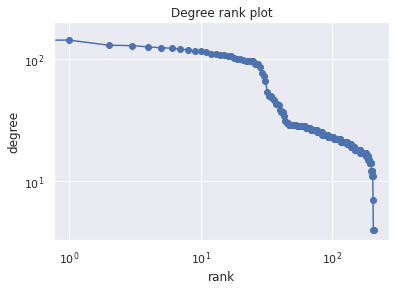

In [ ]:
plot_degree_rank(G)

In [ ]:
# Neighbors for the Higher Degree Node
nb = [ n for n in G['weather sunny'] ]
len(nb)

97

In [ ]:
# Neighbors for the Higher Degree Node - SUBGRAPH
# G_nb = nx.Graph()
# for n in nb:
#   G_nb.add_node(G[n])
nb.append('weather sunny')
G_nb = G.subgraph(nb)

In [ ]:
plt.figure(figsize=(20,12))
nx.draw_circular(G_nb, with_labels=True, )

Output hidden; open in https://colab.research.google.com to view.

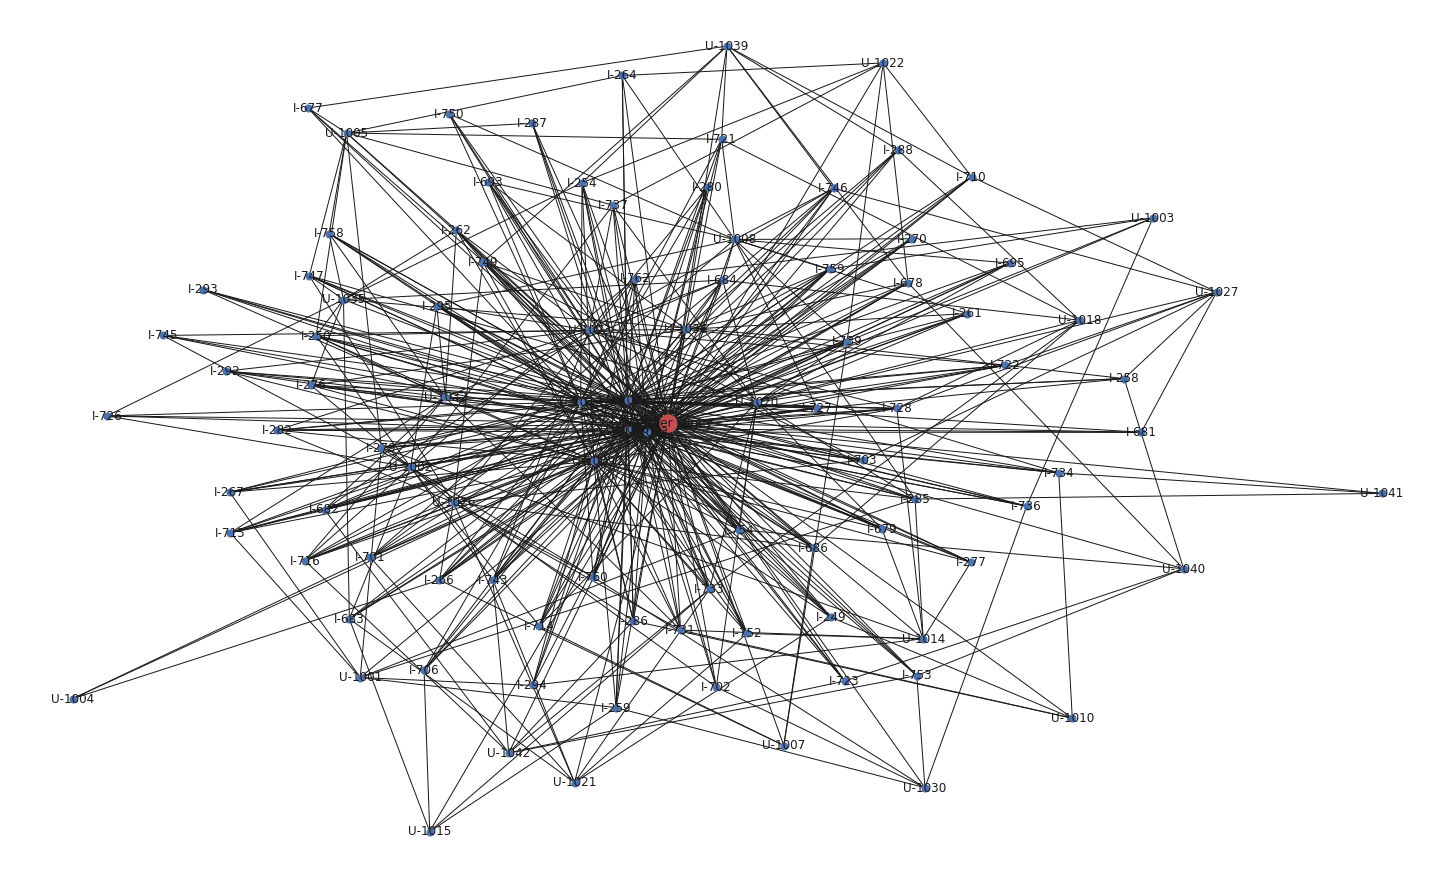

In [ ]:
# n = 1000
# m = 2
# G = nx.generators.barabasi_albert_graph(n, m)
# find node with largest degree
# node_and_degree = G.degree()
# (largest_hub, degree) = sorted(node_and_degree, key=itemgetter(1))[-1]
(largest_hub, degree) = sorted([ (n,d) for n, d in G.degree()], reverse=True)[0]
# Create ego graph of main hub
hub_ego = nx.ego_graph(G, largest_hub)
# Draw graph
pos = nx.spring_layout(hub_ego)
plt.figure(figsize=(20,12))
nx.draw(hub_ego, pos, node_color='b', node_size=50, with_labels=True)
# Draw ego as large and red
nx.draw_networkx_nodes(hub_ego, pos, nodelist=[largest_hub], node_size=300, node_color='r')
plt.show()

In [ ]:
df_nb = filter_df_based_on_subGraph(df, nb)
sparsity(df_nb)

0.9999238272229297

In [ ]:
# Test Sparsity for all subgroups
degree_nodes = sorted([n for n, d in G.degree()], reverse=True)
for node in degree_nodes:
  nb = [ n for n in G[node] ] # Neighbors
  nb.append(node) # The node
  df_nb = filter_df_based_on_subGraph(df, nb)
  sparsity(df_nb)

In [ ]:
# len(list_users)
# len(df['UserID'].unique())
# sparsity(df_nb)
# df_nb.notnull().sum()

df[ df['UserID'].isin(list_users) |  df['ItemID'].isin(list_items)  ].drop_duplicates()

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# list(G)
[x for x in G.nodes() ]
# [n for n, d in G.nodes()]

# r = transform_context_in_graph_element(df, 'landscape')
# r
# colName = 'landscape'
# df_append['Target'] = 'C-' + colName + '-' + df[df[colName].notna() ][colName].astype(str)

# df_graph.append(r)
# df_graph
# df.columns[3:]

# colName = 'DrivingStyle'
# df[df[colName].notna() ][colName]


# Segment GRAPH (just I x U )

In [ ]:
df_graph = pd.DataFrame()
df_graph['Source'] = 'U-'+df['UserID'].astype(str)
df_graph['Target'] = 'I-'+df['ItemID'].astype(str)
df_graph['Rating'] = df[' Rating'].astype(str)

# for colTitle in df.columns[3:]:
#   df_graph = df_graph.append( transform_context_in_graph_element(df, colTitle), ignore_index=True )

df_graph = df_graph.drop_duplicates().reset_index()

df_graph

2020-08-31 18:55:35,819 [INFO]  NumExpr defaulting to 2 threads.


,index,Source,Target,Rating
0,0,U-1001,I-715,2
1,1,U-1001,I-267,4
2,2,U-1001,I-294,2
3,3,U-1001,I-259,4
4,4,U-1001,I-674,2
...,...,...,...,...
1909,3978,U-1042,I-691,1
1910,3979,U-1042,I-257,1
1911,3980,U-1042,I-753,1
1912,3986,U-1042,I-716,1


In [ ]:
G1 = nx.from_pandas_edgelist(df=df_graph, source='Source', target='Target', edge_attr='Rating')

Node with high Degree:  U-1042
Degree: 10


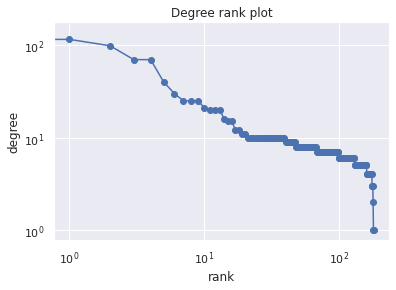

In [ ]:
plot_degree_rank(G1)


In [ ]:
largest_hub, degree = node_high_degree(G1)
print(largest_hub)
print(degree)

In [ ]:
nb = [ n for n in G1[largest_hub] ]
len(nb)

10

In [ ]:
df_nb = filter_df_based_on_subGraph(df, nb)
df_nb.notnull().sum()
sparsity(df_nb)

0.9998460401845451

In [ ]:
# Verify if it is possible a smaller sparsity
list_nodes_desc_degre = sorted([ n for n, d in G1.degree()], reverse=True)
for hub in list_nodes_desc_degre:
  nb = [ n for n in G1[hub] ]
  df_nb = filter_df_based_on_subGraph(df, nb)
  print('Hub: ', hub )
  print('Hub: ', hub, 'Sparsity: ', sparsity(df_nb) )

# SEGMENT U-I

In [ ]:
#Separete TRAIN and TEST
df = dfOri.copy()
np.random.seed(2)
msk = np.random.rand(len(df)) < 0.8
df_train = df[msk]
df_test = df[~msk]
print(len(df_train),' - ', len(df_test))

3216  -  796


In [ ]:
df_UI = merge_2_columns(df_train, 'UserID', 'ItemID', delete_Original_Columns = 1)
df_UI_context = tranform_matrix_context_values_as_columns_with_ratings(df_UI, Ratings_Column = ' Rating')
df_UI_context

,UI,main,DrivingStyle-relaxed driving,DrivingStyle-sport driving,landscape-urban,landscape-mountains,landscape-country side,landscape-coast line,mood-sad,mood-lazy,mood-active,mood-happy,naturalphenomena -night,naturalphenomena -morning,naturalphenomena -day time,naturalphenomena -afternoon,RoadType-city,RoadType-serpentine,RoadType-highway,sleepiness-sleepy,sleepiness-awake,trafficConditions-traffic jam,trafficConditions-lots of cars,trafficConditions-free road,weather-sunny,weather-snowing,weather-rainy,weather-cloudy
0,1001-715,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,NaN
1,1001-267,4.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,1001-294,2.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3,1001-259,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0
4,1001-674,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
924,1042-691,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
925,1042-257,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
926,1042-753,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
927,1042-716,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
basic_sparsity(df_UI_context)

0.8432262032907889

In [ ]:
#Correlation of columns
prof = ProfileReport(df_UI_context)
prof

Output hidden; open in https://colab.research.google.com to view.

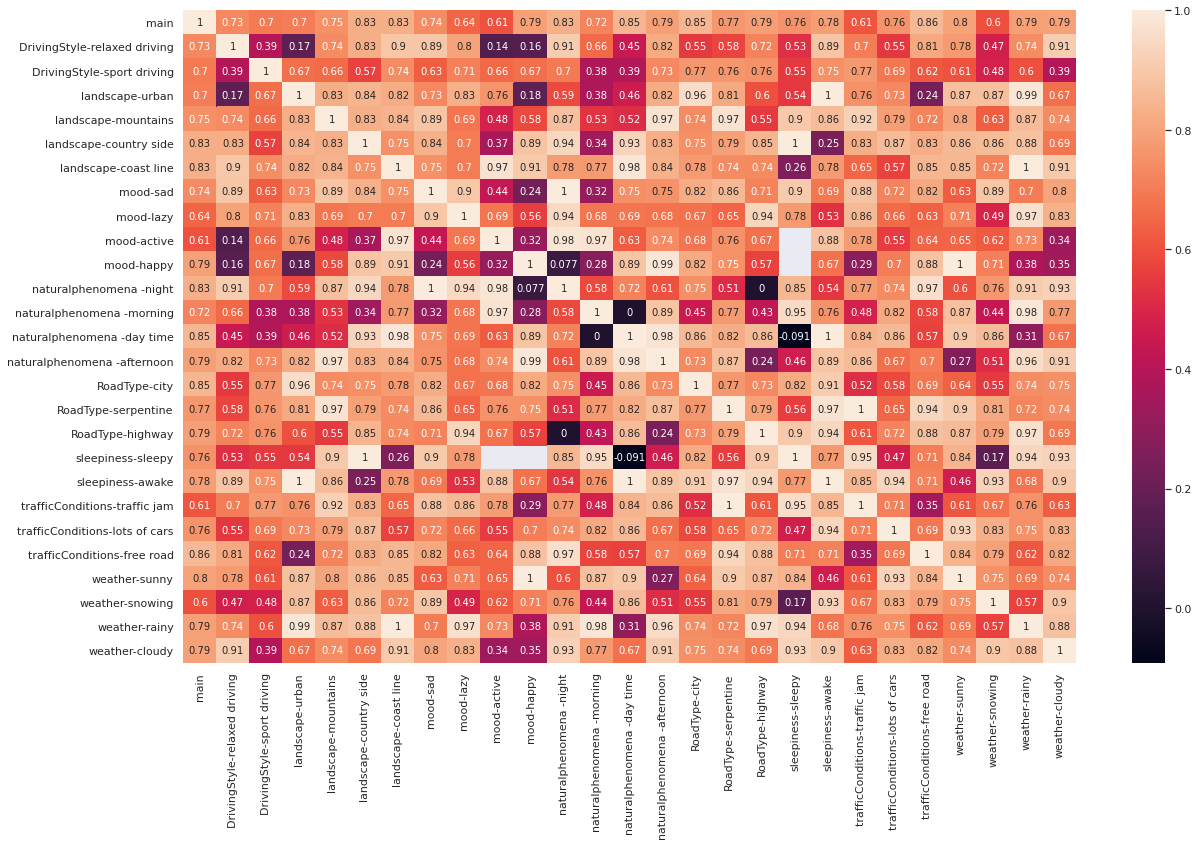

In [ ]:
plot_heatmap_correlation(df_UI_context)

In [ ]:
%cd /content/drive/My\ Drive/CARS/Datasets/
CARSKit_test(df_train)

/content/drive/My Drive/CARS/Datasets


(0.737788, 1.022164)

#MOST FREQUENT IMPUTATION

In [ ]:
%cd /content/drive/My\ Drive/CARS/Datasets/
(dict_Test_Results, lst_correlated_columns) = collect_ALL_MAE_SPARSITY(df_train, correlation_treshold_value = 0.99, imputation_option='MOST_FREQUENT' )

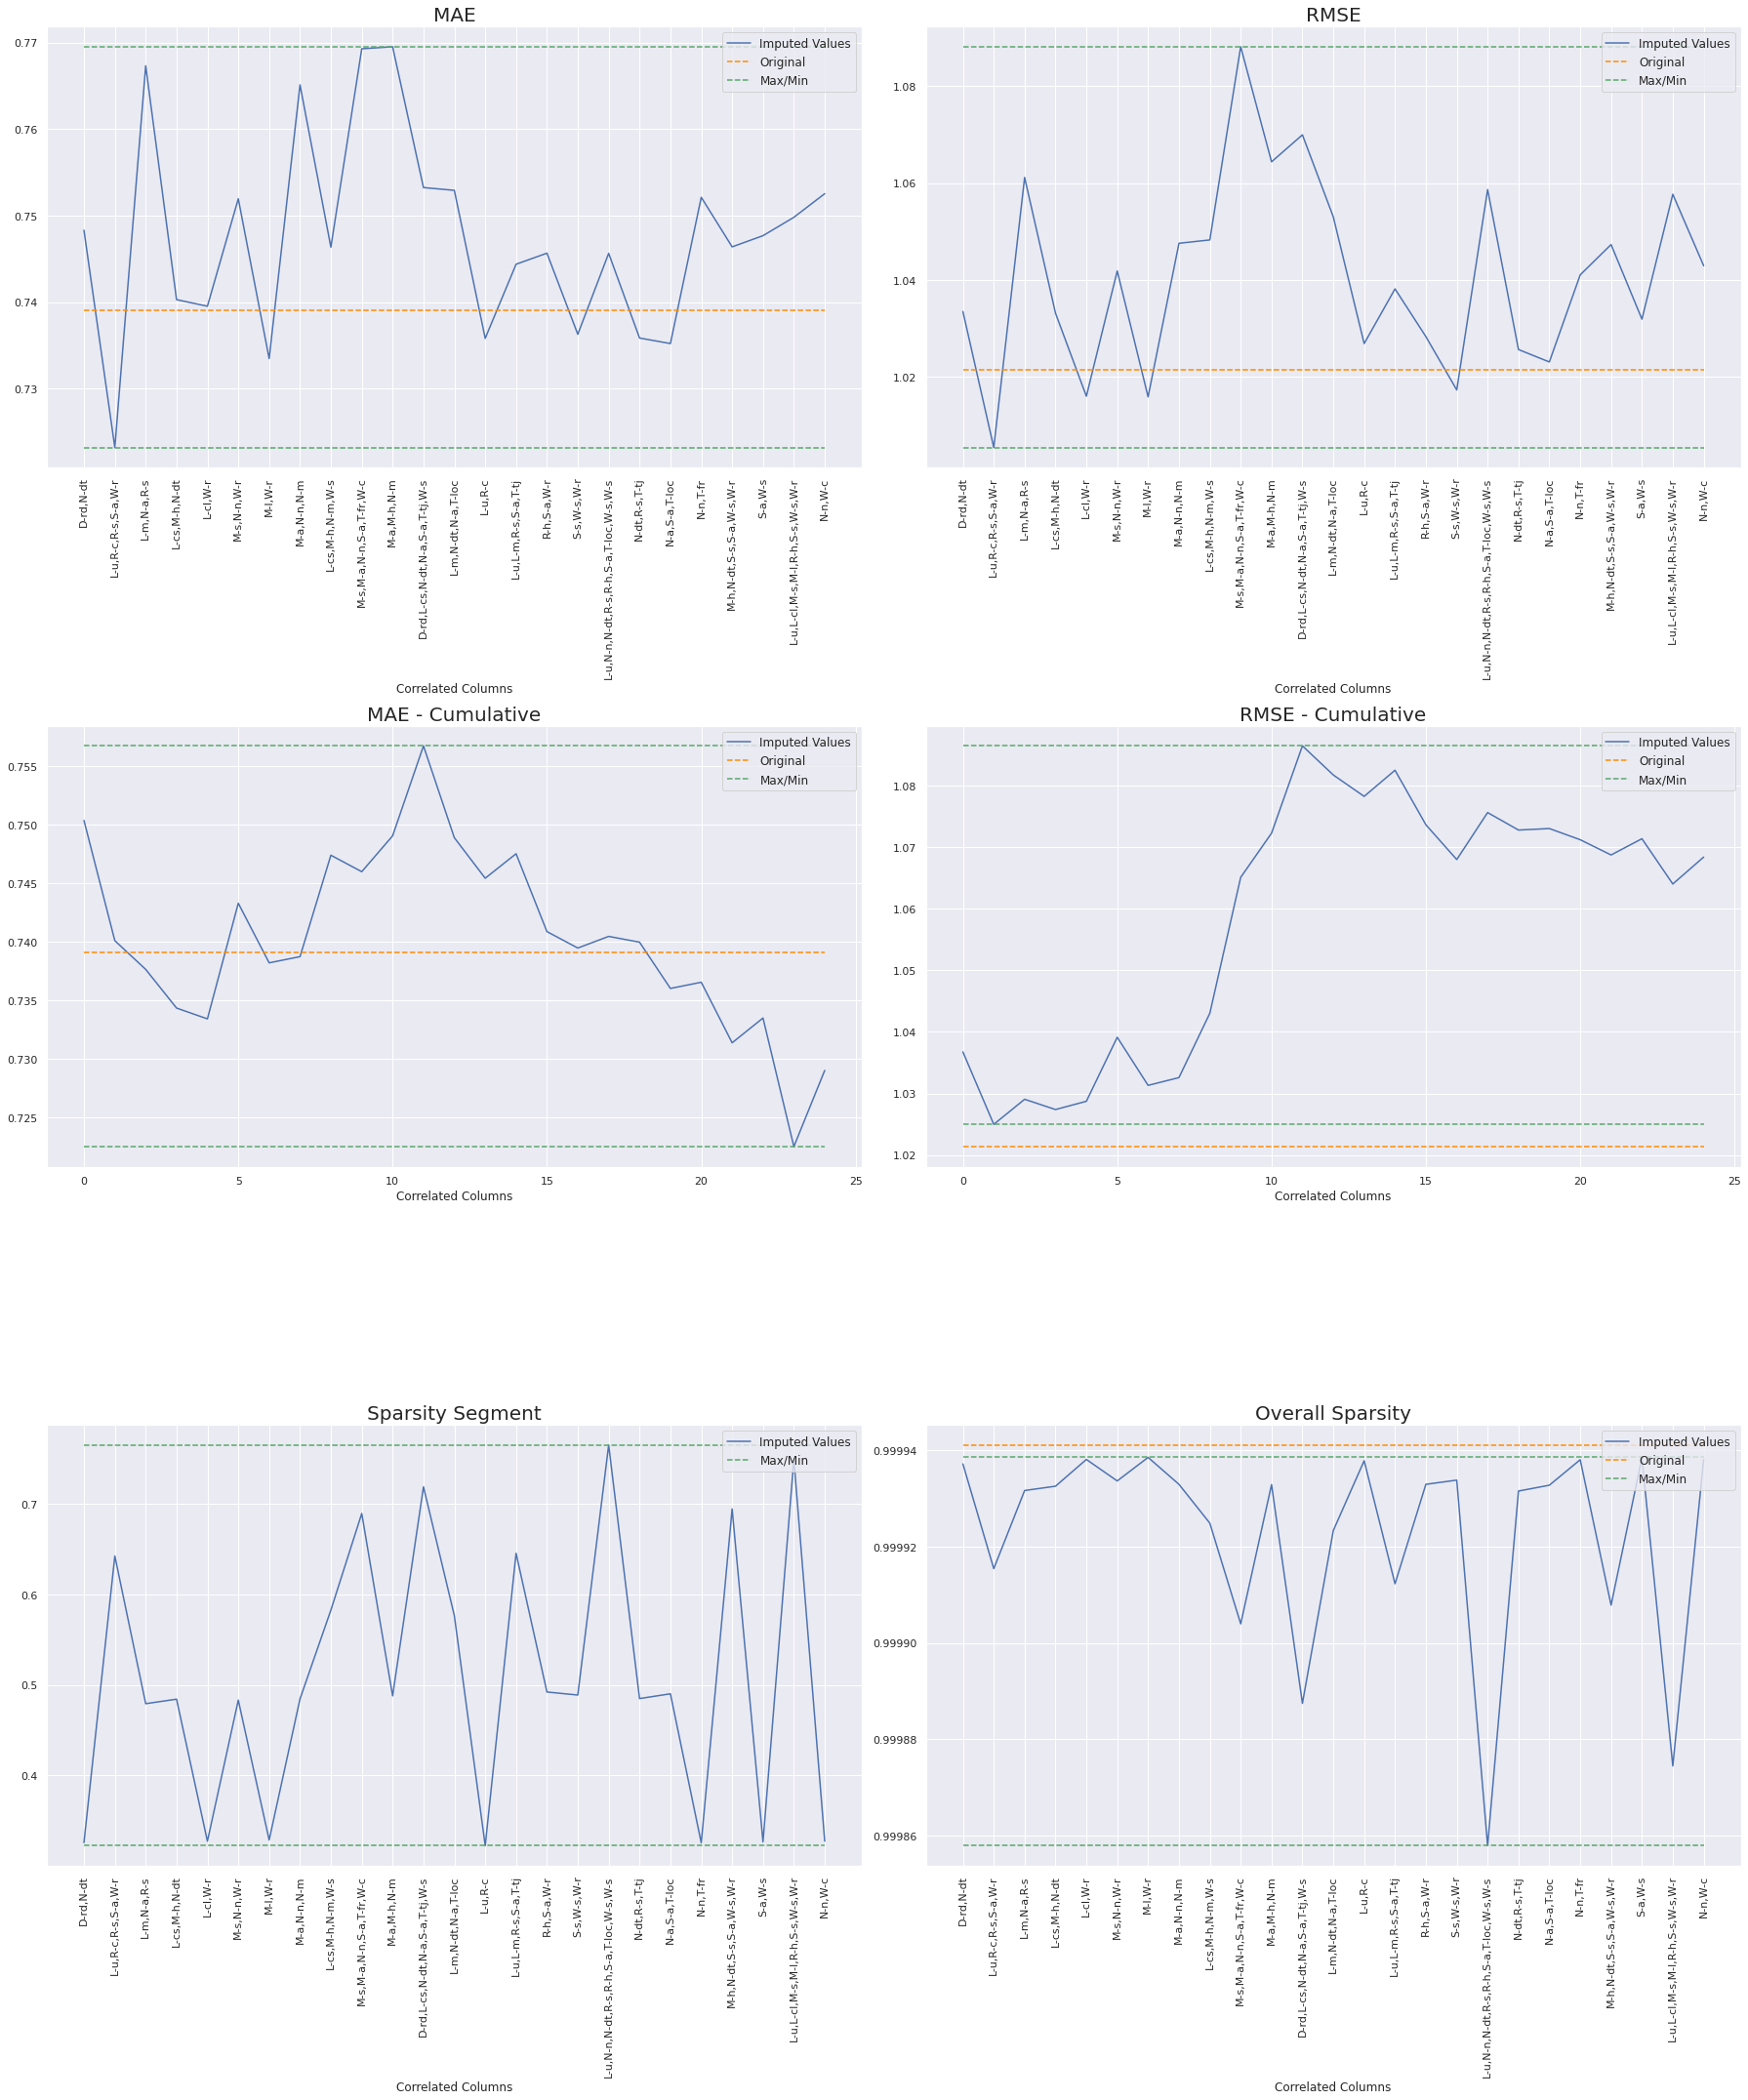

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns )

plot_ALL_MAE_SPARSITY(dict_Test_Results, title_initial_ticks)

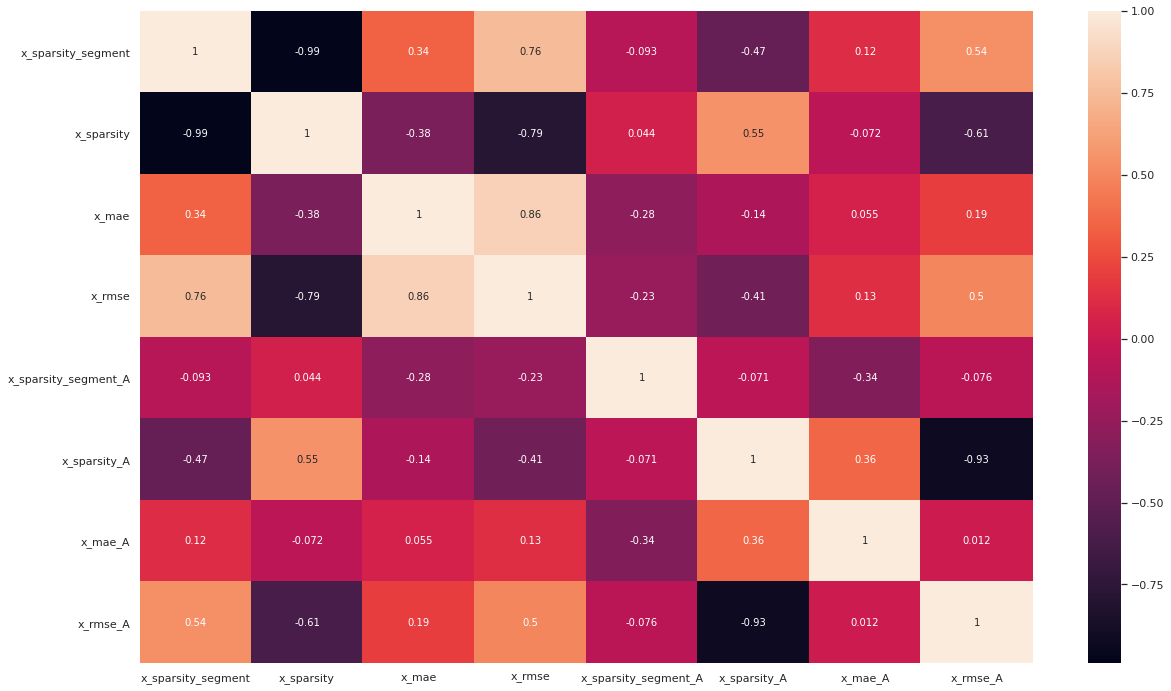

In [ ]:
#Correlation with the results.
plot_heatmap_correlation(tranform_dict_results_in_DF(dict_Test_Results).corr())

In [ ]:
l1,l2 = CARSKit_test_REPEAT(df_train, 3)


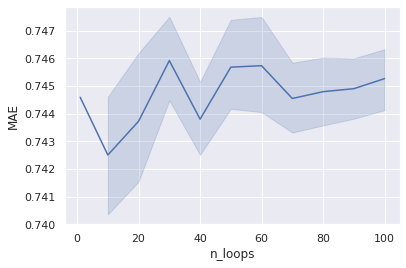

In [ ]:
#Test the Stability of CARS_kit tests
df1 = pd.DataFrame({"n_loops":[],
                    "MAE":[],
                    "RMSE":[]})
for n in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
# for n in [2, 3]:
  l1,l2 = CARSKit_test_REPEAT(df_train, n)
  for p in range(0, len(l1)):
    df1.loc[ len(df1) ]= [n, l1[p], l2[p]]

ax = sns.lineplot(x="n_loops", y="MAE", markers=True, data=df1)

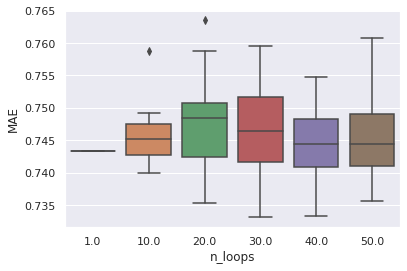

In [ ]:
ax = sns.boxplot(x="n_loops", y="MAE",  data=df1)

In [ ]:
def CARSKit_test_REPEAT(dfp, num_repetitions=1):
  MAE_lst, RMSE_lst = [], []
  for _ in range(0,num_repetitions):
    ( MAE_seg, RMSE_seg ) = CARSKit_test(dfp)
    MAE_lst.append(MAE_seg)
    RMSE_lst.append(RMSE_seg)
  return (MAE_lst, RMSE_lst)

def collect_ALL_MAE_SPARSITY(dfp1, correlation_treshold_value = CORRELATION_TRESHOLD, imputation_option='MOST_FREQUENT', num_repetitions=1 ):
  dfp=dfp1.copy()
  df_UI = merge_2_columns(dfp, 'UserID', 'ItemID', delete_Original_Columns = 1)
  df_UI_context = tranform_matrix_context_values_as_columns_with_ratings(df_UI, Ratings_Column = ' Rating')

  corr = df_UI_context.corr()
  lst_lst_corr = lst_lst_of_correlated_contexts(corr, correlation_treshold_value)

  df_ALL_inputed = dfp.copy()
  df_ALL_better = dfp.copy()
  SPARSITY_SEGMENT_BASIC = 0
  SPARSITY_IMPUTATED_OVERALL = sparsity(dfp)
  ( MAE_Ori, RMSE_Ori ) = CARSKit_test_REPEAT(dfp, num_repetitions)

  dict_CARSKIT_Results = {}
  dict_CARSKIT_Results['Original'] = ('Original', SPARSITY_SEGMENT_BASIC, SPARSITY_IMPUTATED_OVERALL, MAE_Ori, RMSE_Ori )
  print(dict_CARSKIT_Results)
  print('Length List of Correlated Columns: ', len(lst_lst_corr))

  for lst_col in lst_lst_corr:

    # Filter Correlated Columns
    df_fc = filter_columns(df_UI_context, lst_col)

    # Input Values in Correlated
    if imputation_option == 'MOST_FREQUENT':
      df_fc_inputed = input_value_to_nan(df_fc)
    elif imputation_option =='DATAWIG':
      df_fc_inputed = datawig.SimpleImputer.complete(df_fc)
    elif imputation_option =='FM':
      df_fc_inputed = input_value_using_FM(df_fc)

    # Transform Back to Original Format
    df_fc_inputed = df_fc_inputed.drop_duplicates()
    df_fc_inputed_Compact = transform_back_Context_to_Compact(df_fc_inputed, df)
    df_fc_inputed_Compact = df_fc_inputed_Compact.drop_duplicates()

    # Test MAE/RMSE:
    print(lst_col)
    ( MAE_seg, RMSE_seg ) = CARSKit_test_REPEAT(dfp.append(df_fc_inputed_Compact), num_repetitions)
    SPARSITY_SEGMENT_BASIC = basic_sparsity(df_fc)
    SPARSITY_IMPUTATED_OVERALL = sparsity(dfp.append(df_fc_inputed_Compact))
    print( SPARSITY_IMPUTATED_OVERALL, ' - ', MAE_seg, ' - ',  RMSE_seg)
    dict_CARSKIT_Results[ ', '.join(lst_col) ] = ('Segment', SPARSITY_SEGMENT_BASIC, SPARSITY_IMPUTATED_OVERALL, MAE_seg, RMSE_seg )

    # Append to Completed Inputed
    df_ALL_inputed = df_ALL_inputed.append(df_fc_inputed_Compact)
    print('All_inputed:')
    SPARSITY_SEGMENT_BASIC = basic_sparsity(pd.concat([df_ALL_inputed, df_train, df_train]).drop_duplicates(keep=False))
    SPARSITY_IMPUTATED_OVERALL = sparsity(df_ALL_inputed)
    ( MAE, RMSE ) = CARSKit_test_REPEAT(df_ALL_inputed, num_repetitions )
    print(SPARSITY_IMPUTATED_OVERALL, '- ',  MAE, ' - ',  RMSE)
    dict_CARSKIT_Results['ALL-' + ', '.join(lst_col) ] = ('ALL', SPARSITY_SEGMENT_BASIC, SPARSITY_IMPUTATED_OVERALL, MAE, RMSE )

    # # Append to Just Better Results
    # if MAE_seg <= MAE_Ori:
    #   df_ALL_better = df_ALL_better.append(df_fc_inputed_Compact)
    #   print('All_Better:')
    #   SPARSITY_SEGMENT_BASIC = basic_sparsity(pd.concat([df_ALL_better, df_train, df_train]).drop_duplicates(keep=False))
    #   SPARSITY_IMPUTATED_OVERALL = sparsity(df_ALL_better)
    #   ( MAE, RMSE ) = CARSKit_test(df_ALL_better)
    #   print(SPARSITY_IMPUTATED_OVERALL, '- ',  MAE, ' - ',  RMSE)
    #   dict_CARSKIT_Results['BETTER-' + ', '.join(lst_col) ] = ('BETTER', SPARSITY_SEGMENT_BASIC, SPARSITY_IMPUTATED_OVERALL, MAE, RMSE )

  return dict_CARSKIT_Results, lst_lst_corr

In [ ]:
(dict_Test_Results, lst_correlated_columns) = collect_ALL_MAE_SPARSITY(df_train, correlation_treshold_value = 0.99, imputation_option='MOST_FREQUENT' )

In [ ]:
for (t,sparsity_seg, sparsity_imputated, MAE, RMSE) in dict_Test_Results.values():
  if t == 'Original':
    print(MAE)
  if t == 'BETTER':
    print(MAE)

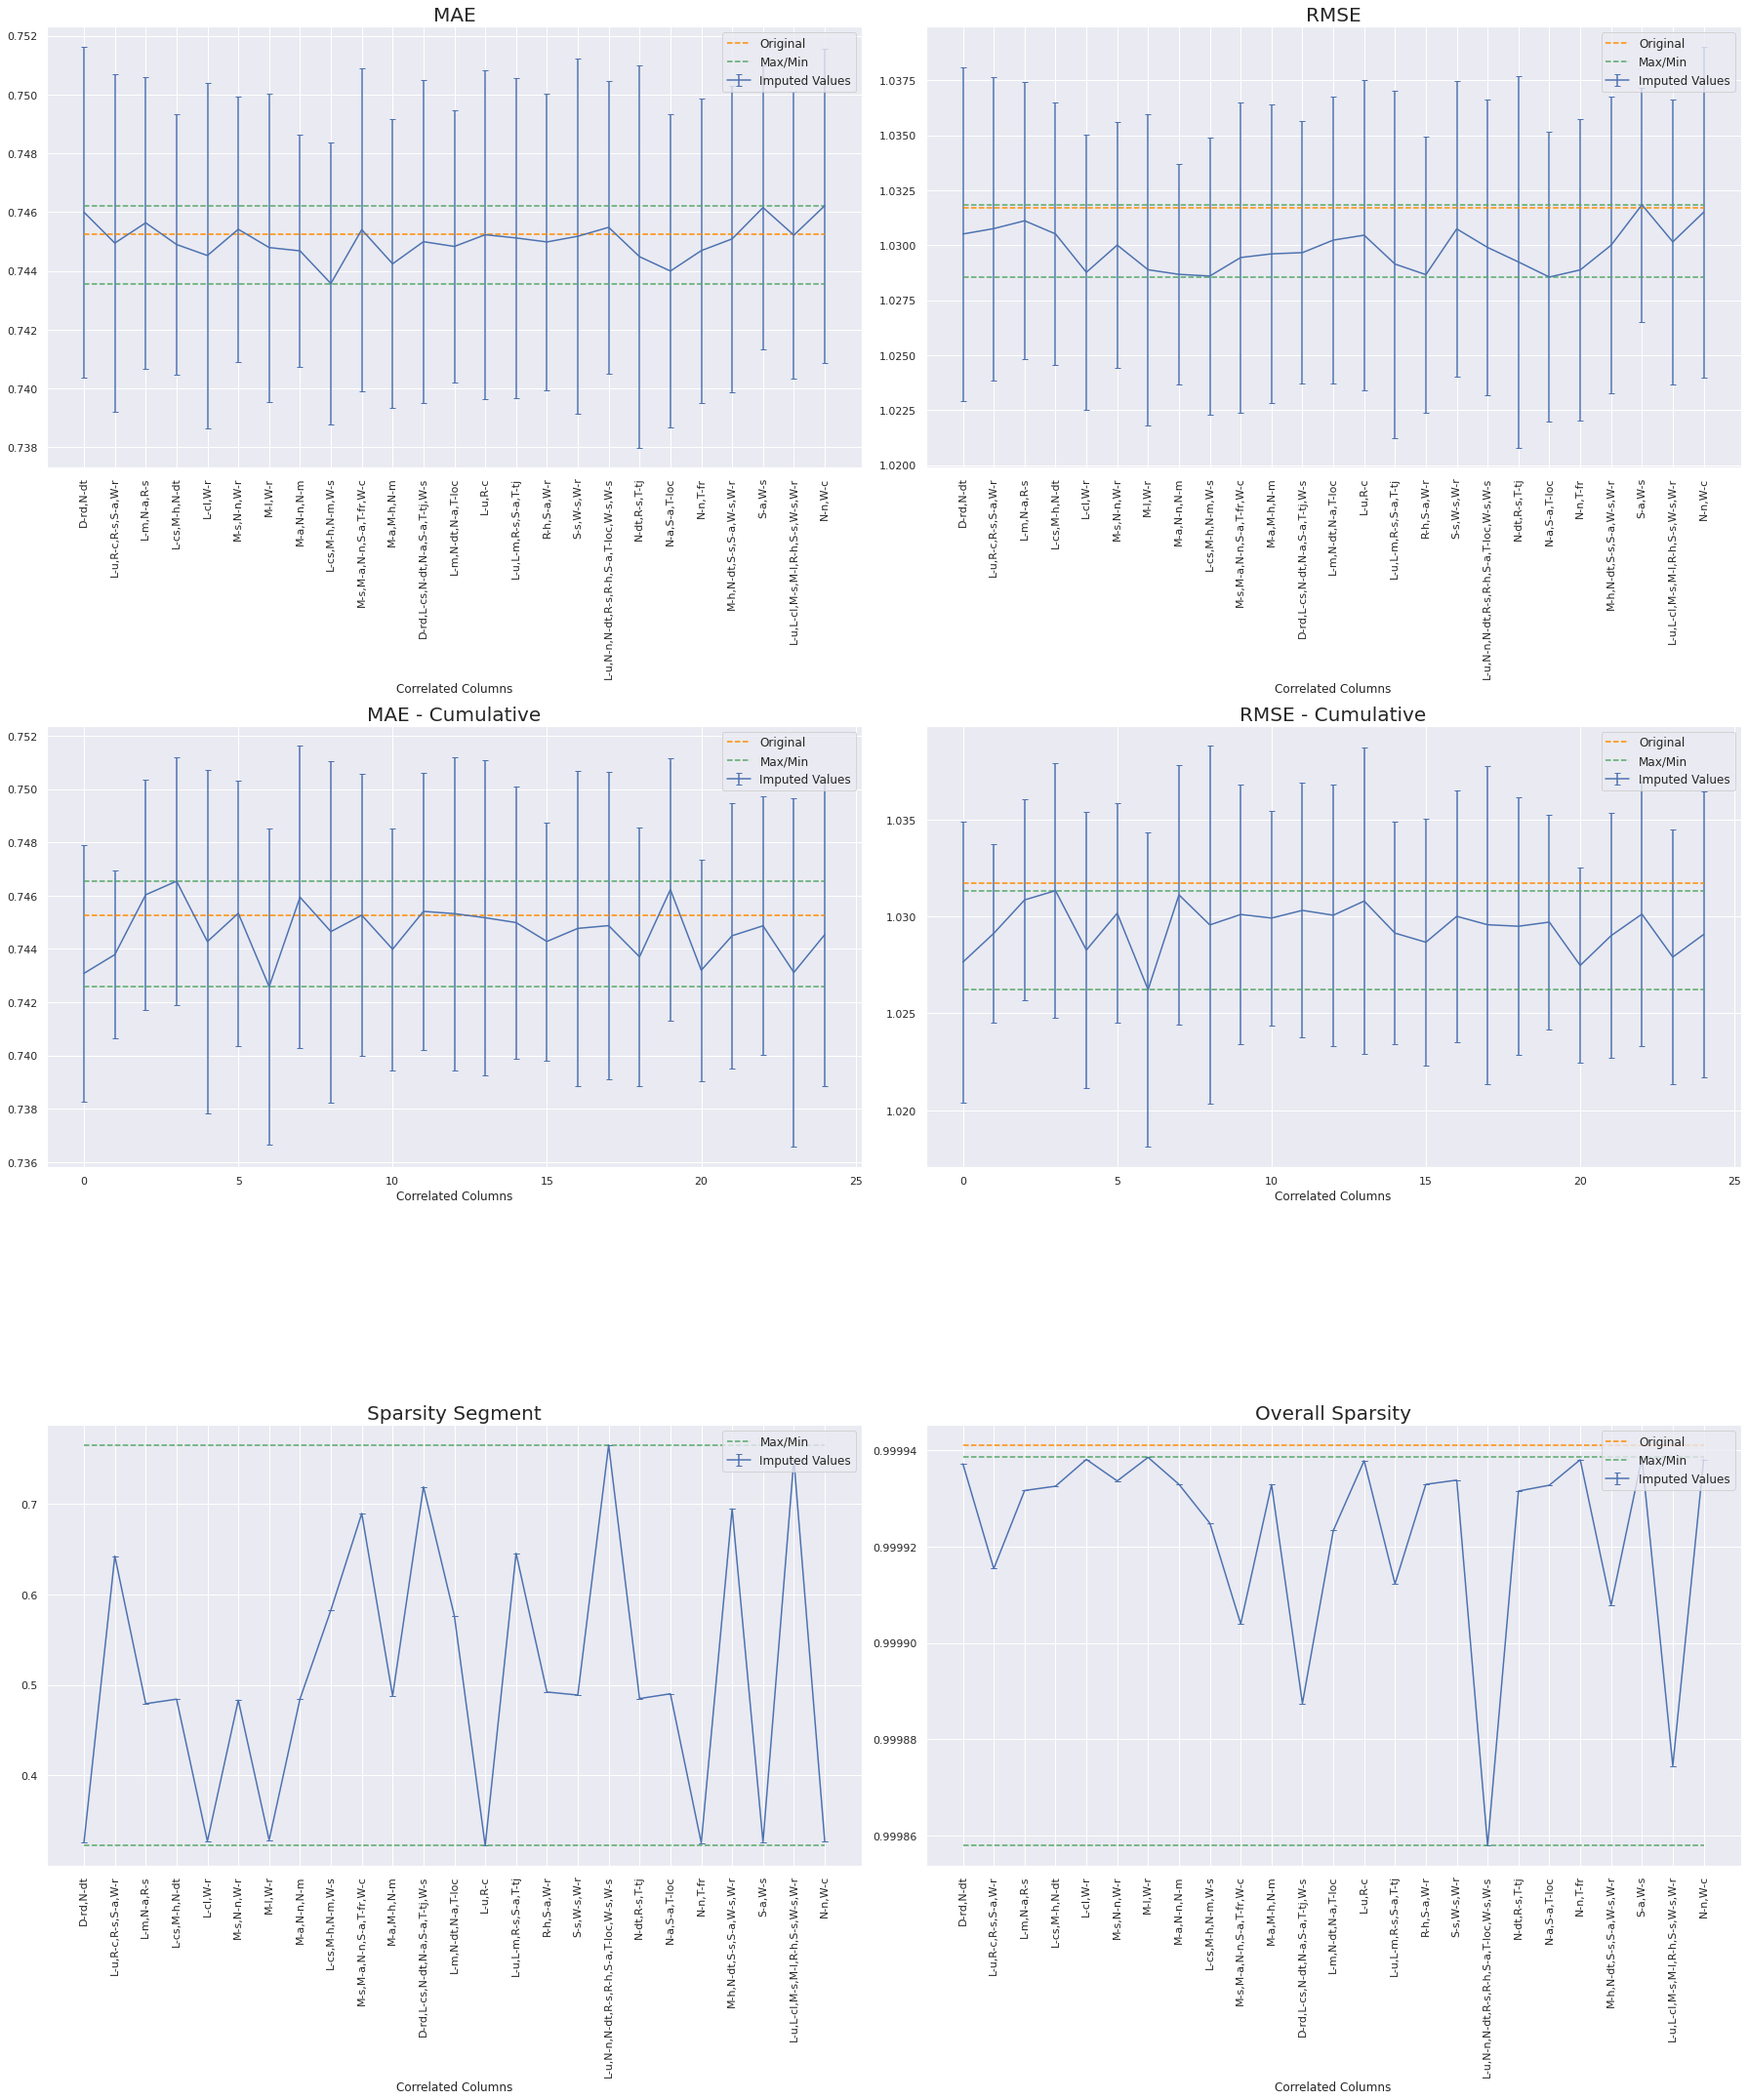

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns2 )

plot_ALL_MAE_SPARSITY(dict_Test_Results2, title_initial_ticks)

#Factorization Machine

In [ ]:
!pip install fastFM

     |████████████████████████████████| 491kB 3.9MB/s 


In [ ]:
from fastFM import als

fm = als.FMRegression(n_iter=1000, init_stdev=0.1, rank=2, l2_reg_w=0.1, l2_reg_V=0.5)

In [ ]:
from scipy.sparse import lil_matrix

def transform_Pandas_to_SparseMatrix(dfp):
  sparse_matrix = lil_matrix((dfp.index.max()+1, len(dfp.columns)))
  for k, column_name in enumerate(dfp.columns):
    sparse_matrix[dfp.index.values, np.full(len(dfp), k)] = dfp[column_name].values
  return sparse_matrix.tocsr()



In [ ]:
df=df_train.copy()
df_UI = merge_2_columns(df, 'UserID', 'ItemID', delete_Original_Columns = 1)
df_UI_context = tranform_matrix_context_values_as_columns_with_ratings(df_UI, Ratings_Column = ' Rating')

corr = df_UI_context.corr()
lst_lst_corr = lst_lst_of_correlated_contexts(corr)

df_ALL_inputed = df.copy()
dict_CARSKIT_Results = {}
dict_CARSKIT_Results['Original'] = CARSKit_test(df)
print(dict_CARSKIT_Results)
print('Length List of Correlated Columns: ', len(lst_lst_corr))

{'Original': (0.744859, 1.031496)}
Length List of Correlated Columns:  26


In [ ]:
for lst_col in lst_lst_corr[2:3]:

  # Filter Correlated Columns
  df_fc = filter_columns(df_UI_context, lst_col)

  # # Input Values in Correlated
  # df_fc_inputed = input_value_to_nan(df_fc)

  # # Transform Back to Original Format
  # df_fc_inputed_Compact = transform_back_Context_to_Compact(df_fc_inputed, df)

  # # Test MAE/RMSE:
  # print(lst_col)
  # ( MAE, RMSE ) = CARSKit_test(df.append(df_fc_inputed_Compact))
  # print( MAE, ' - ',  RMSE)
  # dict_CARSKIT_Results[ ', '.join(lst_col) ] = ( MAE, RMSE )

  # # Append to Completed Inputed
  # df_ALL_inputed = df_ALL_inputed.append(df_fc_inputed_Compact)
  # print('All_inputed:')
  # ( MAE, RMSE ) = CARSKit_test(df_ALL_inputed)
  # print( MAE, ' - ',  RMSE)
  # dict_CARSKIT_Results['ALL-' + ', '.join(lst_col) ] = ( MAE, RMSE )

In [ ]:
lst = lst_lst_corr[2:3]
# lst[0][1]
col_treat = lst[0][1]
df_fc_train = df_fc[ df_fc[col_treat].notna() ]
features_cols = df_fc.columns.to_list()
features_cols.remove('UI')
features_cols.remove(col_treat)

X = df_fc_train.loc[:,features_cols]

#Remove ROW with all NAN (in Features)
df_fc_train = df_fc_train[ ~X.isna().all(axis=1) ]

X = df_fc_train.loc[:,features_cols]
y = df_fc_train[col_treat].to_numpy()



In [ ]:
#Drop Columns with all NAN
X = X.dropna(how='all') # Rows all NAN
X = X.dropna(how='all', axis=1) # Column all NAN

#Transform Pandas to NP Sparse Matrix:
sX = transform_Pandas_to_SparseMatrix(X.fillna(0))


In [ ]:
sX

<847x6 sparse matrix of type '<class 'numpy.float64'>'
	with 28 stored elements in Compressed Sparse Row format>

In [ ]:
fm.fit(sX, y)
# y_pred = fm.predict(sX_test)

AssertionError: ignored

In [ ]:
from fastFM.datasets import make_user_item_regression
from sklearn.model_selection import train_test_split

# This sets up a small test dataset.
X, y, _ = make_user_item_regression(label_stdev=.4)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
fm = als.FMRegression(n_iter=1000, init_stdev=0.1, rank=2, l2_reg_w=0.1, l2_reg_V=0.5)
fm.fit(X_train, y_train)
y_pred = fm.predict(X_test)

# Lib Factorization Machine


In [ ]:
NUM_REPETITIONS_TESTS=30
IMPUTATION_METHOD='FM'
# IMPUTATION_METHOD='MOST_FREQUENT'
# IMPUTATION_METHOD='DATAWIG'


In [ ]:
#Read from Saved File
dict_Test_Results2 = load_obj('Dict_Results_' + str(IMPUTATION_METHOD) + '_' + str(NUM_REPETITIONS_TESTS))
lst_correlated_columns2 = load_obj('lst_correlated_Results_' + str(IMPUTATION_METHOD) + '_' + str(NUM_REPETITIONS_TESTS))

#RUN
# (dict_Test_Results2, lst_correlated_columns2) = collect_ALL_MAE_SPARSITY(df_train, correlation_treshold_value = 0.99, imputation_option=IMPUTATION_METHOD,  num_repetitions=NUM_REPETITIONS_TESTS)

# #Save DICT Results and Columns:^
# save_obj(dict_Test_Results2, 'Dict_Results_' + str(IMPUTATION_METHOD) + '_' + str(NUM_REPETITIONS_TESTS) )
# save_obj(lst_correlated_columns2, 'lst_correlated_Results_' + str(IMPUTATION_METHOD) + '_' + str(NUM_REPETITIONS_TESTS) )

In [ ]:
def subplot_base(y, x_list, x_ori_list, title='', y_ticks='' ):

  x, x_error = collect_mean_std_from_list(x_list)
  x_ori =  np.mean( x_ori_list )


  plt.plot(y, x, label='Imputed Values')
  # plt.errorbar(y, x, x_error, capsize=3, label='Imputed Values')
  if x_ori != 0:
    plt.plot(y, [x_ori for i in range(len(x))], '--', color='darkorange', label='Original' )

  plt.plot(y, [min(x) for i in range(len(x))], 'g--' , label='Max/Min')
  plt.plot(y, [max(x) for i in range(len(x))], 'g--' )
  plt.title(title, fontsize=20)
  plt.xlabel('Correlated Columns', fontsize=12)
  plt.legend(loc='upper right', fontsize=12)
  if len(y_ticks) == len(y):
    plt.xticks(y, y_ticks, rotation=90)

def collect_mean_std_from_list(x_list):
  #if x is a list of list create new x with mean and the error
  x = []       # x_mean
  x_error = []
  for i_list in x_list:
    x.append( np.mean(i_list) )
    x_error.append( np.std(i_list) ) #Std_Deviation
  return x, x_error

In [ ]:
def plot_ALL_MAE_SPARSITY(dict_results, x_ticks_Initials = ''):
  #Collect Dict info like list
  x_sparsity_segment, x_sparsity, x_mae, x_rmse, x_sparsity_segment_A, x_sparsity_A, x_mae_A, x_rmse_A, x_sparsity_segment_Original, x_sparsity_Original, x_mae_Original, x_rmse_Original = collect_list_results_from_dict(dict_results)
  #PLOT Results:

  Y = range(len(x_mae))

  fig = plt.figure(figsize=(18,25))

  plt.subplot(3,2,1)
  subplot_base(Y, x_mae, x_mae_Original, 'MAE', x_ticks_Initials)

  plt.subplot(3,2,2)
  subplot_base(Y, x_rmse, x_rmse_Original, 'RMSE', x_ticks_Initials)

  plt.subplot(3,2,3)
  subplot_base(Y, x_mae_A, x_mae_Original, 'MAE - Cumulative')

  plt.subplot(3,2,4)
  subplot_base(Y, x_rmse_A, x_rmse_Original, 'RMSE - Cumulative')

  plt.subplot(3,2,5)
  subplot_base(Y, x_sparsity_segment, x_sparsity_segment_Original, 'Sparsity Segment', x_ticks_Initials)

  plt.subplot(3,2,6)
  subplot_base(Y, x_sparsity, x_sparsity_Original, 'Overall Sparsity', x_ticks_Initials)

  plt.tight_layout()
  plt.show()

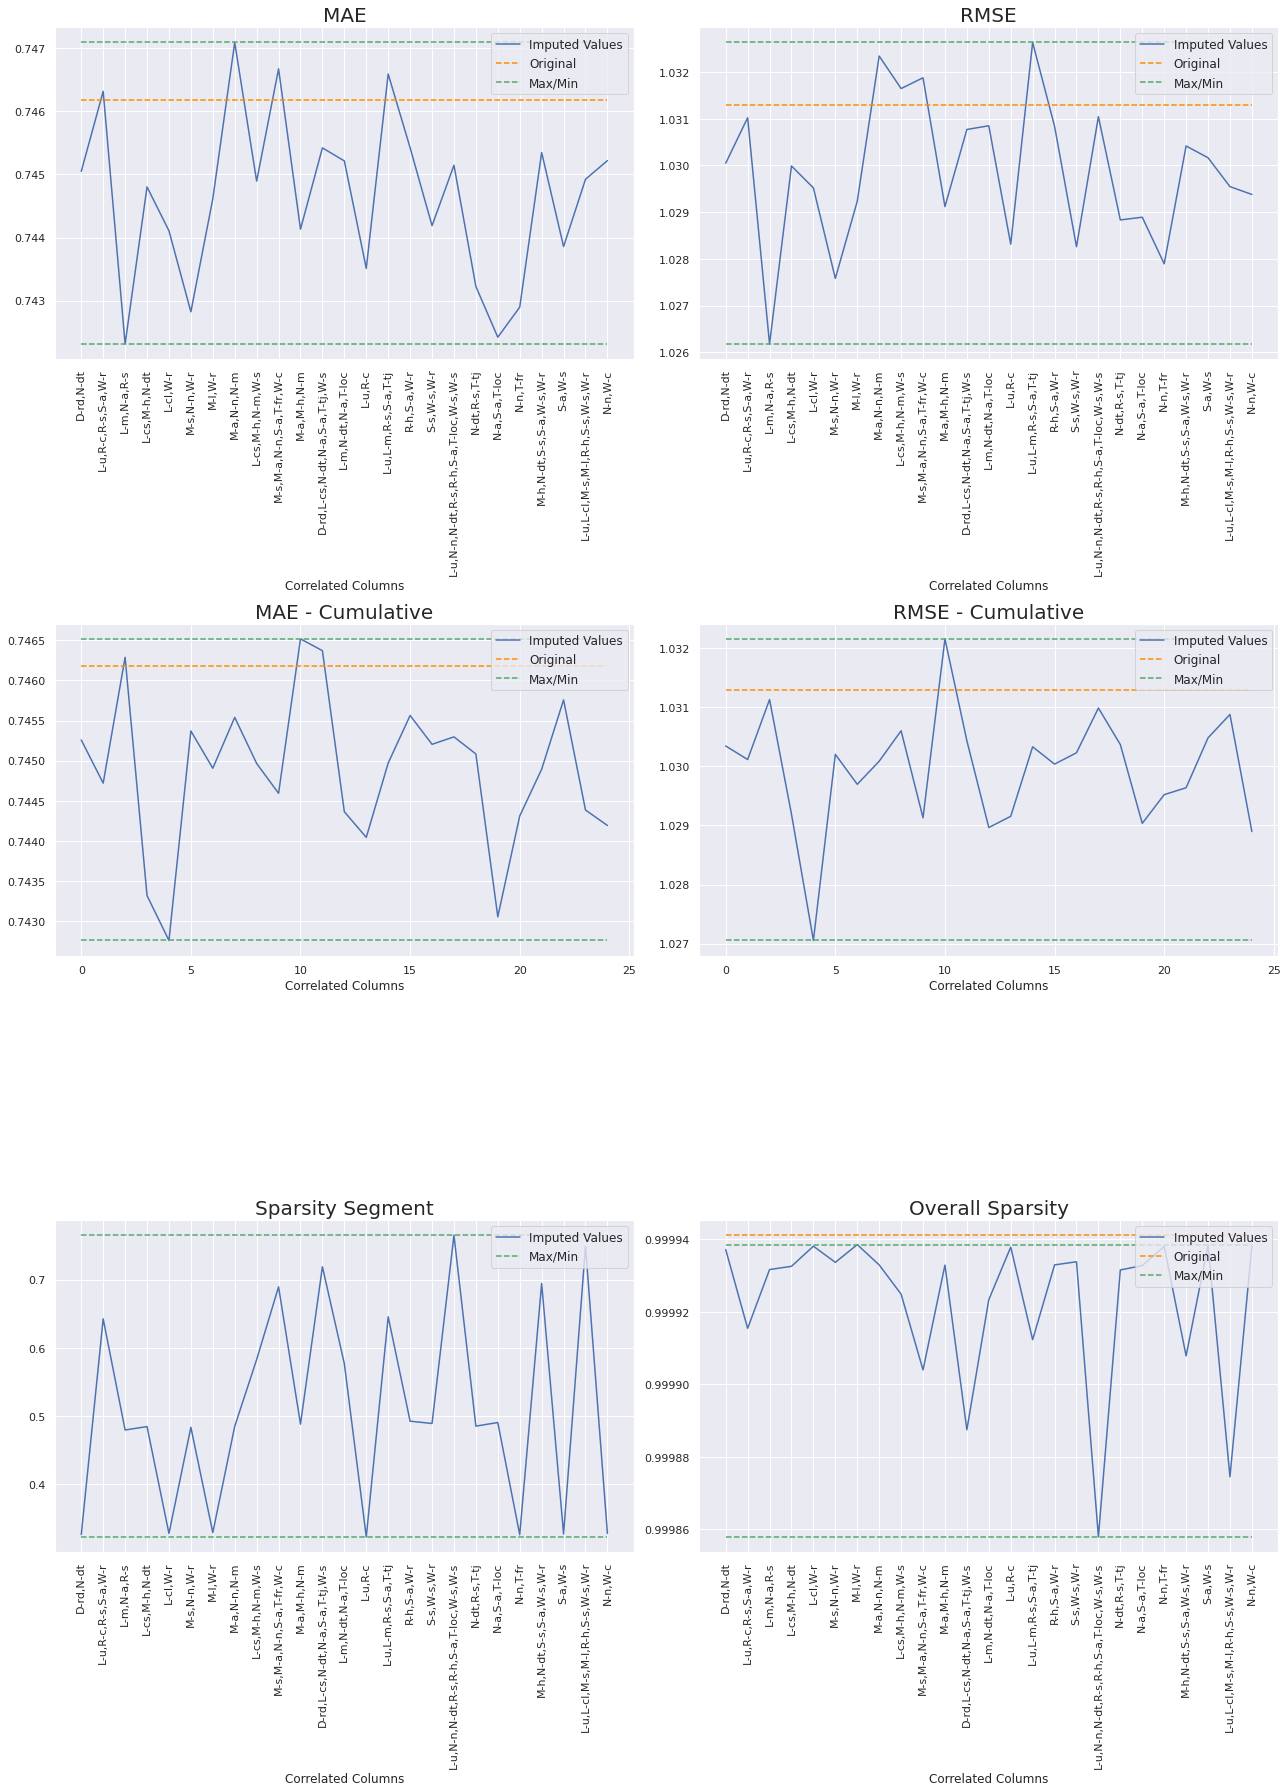

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns2 )

plot_ALL_MAE_SPARSITY(dict_Test_Results2, title_initial_ticks)

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns )

plot_ALL_MAE_SPARSITY(dict_Test_Results, title_initial_ticks)

In [ ]:
import pywFM
import numpy as np
import pandas as pd

features = np.matrix([
#     Users  |     Movies     |    Movie Ratings   | Time | Last Movies Rated
#    A  B  C | TI  NH  SW  ST | TI   NH   SW   ST  |      | TI  NH  SW  ST
    [1, 0, 0,  1,  0,  0,  0,   0.3, 0.3, 0.3, 0,     13,   0,  0,  0,  0 ],
    [1, 0, 0,  0,  1,  0,  0,   0.3, 0.3, 0.3, 0,     14,   1,  0,  0,  0 ],
    [1, 0, 0,  0,  0,  1,  0,   0.3, 0.3, 0.3, 0,     16,   0,  1,  0,  0 ],
    [0, 1, 0,  0,  0,  1,  0,   0,   0,   0.5, 0.5,   5,    0,  0,  0,  0 ],
    [0, 1, 0,  0,  0,  0,  1,   0,   0,   0.5, 0.5,   8,    0,  0,  1,  0 ],
    [0, 0, 1,  1,  0,  0,  0,   0.5, 0,   0.5, 0,     9,    0,  0,  0,  0 ],
    [0, 0, 1,  0,  0,  1,  0,   0.5, 0,   0.5, 0,     12,   1,  0,  0,  0 ]
])
target = [5, 3, 1, 4, 5, 1, 5]

fm = pywFM.FM(task='regression', num_iter=10, seed=1)

# split features and target for train/test
# first 5 are train, last 2 are test
model = fm.run(features[:5], target[:5], features[5:], target[5:])
print(model.predictions)
# you can also get the model weights
print(model.weights)

2579
[4.81546, 4.37516]
[0.781605, 0.612359, 0.876638, -0.431279, 0.20916, -0.285346, 0.419331, 0.4211, -0.342897, -0.0174361, -0.46793, 0.117387, 0.34873, 0.302541, -0.618115]


In [ ]:
dfp=df_train.copy()
df_UI = merge_2_columns(dfp, 'UserID', 'ItemID', delete_Original_Columns = 1)
df_UI_context = tranform_matrix_context_values_as_columns_with_ratings(df_UI, Ratings_Column = ' Rating')
corr = df_UI_context.corr()
lst_lst_corr = lst_lst_of_correlated_contexts(corr, 0.99)


In [ ]:
def input_value_using_FM(df_fc1):
  df_fc1_INPUTED = df_fc1.copy()

  lst_col1 = df_fc1.columns.to_list()
  lst_col1.remove('UI') if 'UI' in lst_col1 else lst_col1
  for colum_treat in lst_col1:
    df_fc1_INPUTED = df_fc1_INPUTED.append ( input_value_from_MODEL(df_fc1, colum_treat) )

  return df_fc1_INPUTED

fm = pywFM.FM(task='regression', num_iter=10, seed=1)

def input_value_from_MODEL(dfp, col_treat):
  df_fc_train = dfp[ dfp[col_treat].notna() ]
  features_cols = df_fc_train.columns.to_list()
  features_cols.remove('UI')
  features_cols.remove(col_treat)

  X = df_fc_train.loc[:,features_cols] # Leave just VARIABLES in X.

  #Remove ROW with all NAN (in Features)
  df_fc_train = df_fc_train[ ~X.isna().all(axis=1) ]

  X = df_fc_train.loc[:,features_cols].fillna(0).to_numpy()
  y = df_fc_train[col_treat].to_numpy()

  #TEST
  df_fc_test = dfp[ ~dfp[col_treat].notna() ]
  X_test = df_fc_test.loc[:,features_cols]

  #Remove ROW with all NAN (in Features)
  df_fc_test = df_fc_test[ ~X_test.isna().all(axis=1) ]
  X_test = df_fc_test.loc[:,features_cols].fillna(0).to_numpy()
  y_test = np.full((len(X_test)), 0) # Just fake '0's values - Don't influence in TRAIN MODEL calculation

  #Apply the Model
  model = fm.run(X, y, X_test, y_test)

  #Input values to DF
  df_fc_test_inputted = df_fc_test.copy()
  df_fc_test_inputted[col_treat] = np.asarray(model.predictions )

  return df_fc_test_inputted


In [ ]:
def filter_columns(dfp1, lst_columns):
  dfp = dfp1.copy()
  lst_columns.insert(0,'UI')  if 'UI' not in lst_columns else lst_columns
  dfp = dfp[lst_columns].copy() # Filter Correlated columns
  dfp = dfp[~dfp.iloc[:,1:].isnull().all(axis=1)]
  return dfp

def transform_back_Context_to_Compact(dfp, dfp_Ori):
  dfp_aux = df.iloc[0:0,:].copy()

  #Incialize Context with NaN values
  dict_contexts = {}

  for i, row in dfp.iterrows():
    (UserID, ItemID) = row['UI'].split('-')

    for colName in row.index[1:]:
      #Set Contexts to NAN
      for colName1 in df.columns[3:]:
        dict_contexts[colName1] = np.nan

      (contextTitle, contextValue) = colName.split('-')
      dict_contexts[contextTitle] = contextValue
      Rating = np.nan if math.isnan(row[colName]) else int(row[colName])

      list_Values = [int(UserID), int(ItemID), Rating, dict_contexts['DrivingStyle'], dict_contexts['landscape'],
                  dict_contexts['mood'], dict_contexts['naturalphenomena '], dict_contexts['RoadType'],
                  dict_contexts['sleepiness'], dict_contexts['trafficConditions'], dict_contexts['weather'] ]
      dfp_aux.loc[len(dfp_aux)] = list_Values

  return dfp_aux

In [ ]:

# lst_col = lst_lst_corr[2]
col_treat = lst_col[1]
df_fc = filter_columns(df_UI_context, lst_col)

# t = input_value_from_MODEL(df_fc1, col_treat)
# t.append( )
t = input_value_using_FM(df_fc)
print(len(t))
print(len(t.drop_duplicates()))
print(len(t))

265
2560
421
2532
577
2556
733
2546
889
889
421
889


In [ ]:
model = fm.run(X, y, X_test, y_test)
print(model.predictions)

2531
[2.82838, 1.23689, 1.23689, 1.02637, 1.02637, 1.88559, 2.31617, 1.88559, 1.23689, 4.6, 4.38375, 1.88559, 1.23689, 1.23689, 2.31617, 3.77118, 1.23689, 4.1138, 3.77118, 2.31617, 1.23689, 4.38375, 2.31617, 3.77118, 1.02637, 2.82838, 1.0, 1.02637, 3.47348, 1.88559, 3.47348, 4.05239, 2.31617, 3.47348, 1.88559, 1.88559, 1.02637, 1.02637, 1.88559, 4.38375, 2.82838, 1.23689, 1.02637, 3.47348, 4.60469, 3.47348, 1.23689, 2.82838, 3.77118, 2.31617, 3.47348, 4.38375, 3.47348, 1.02637, 2.82838, 1.23689, 4.1138, 1.23689, 1.23689, 4.60469, 4.60469, 4.1138, 1.23689, 4.1138, 1.88559, 2.82838, 1.02637, 4.58212, 4.60469, 1.88559, 1.23689, 1.23689, 1.88559, 1.23689, 1.02637, 1.23689, 2.82838, 3.77118, 1.23689, 4.38375, 1.23689, 1.23689, 1.23689, 2.31617, 1.23689, 1.23689, 1.23689, 2.82838, 1.88559, 1.88559, 1.23689, 3.47348, 1.0, 1.0, 2.82838, 2.31617, 4.58212, 2.31617, 3.77118, 4.60469, 4.58212, 3.47348, 3.77118, 1.23689, 2.82838, 3.47348, 4.60469, 2.82838, 1.23689, 2.82838, 2.31617, 4.60469, 3.7711

2509
23023
227949
2281871
22805790
228026660


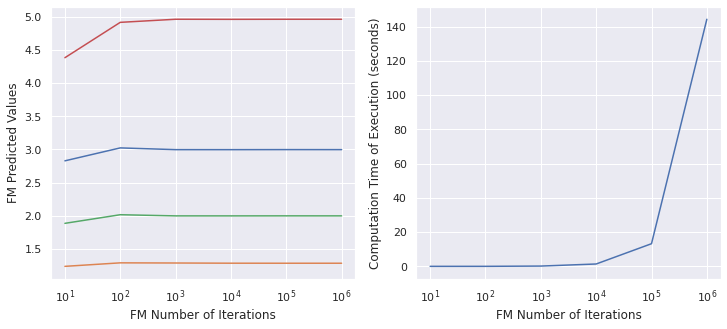

In [ ]:
# Determine best N_ITERATIONS
import time
pred1 = []
pred2 = []
pred3 = []
pred4 = []
timeY = []
n_iter = []
n = 10
while n <= 1e6:
  start_time = time.time()
  fm = pywFM.FM(task='regression', num_iter=n, seed=1)
  model = fm.run(X, y, X_test, y_test)
  pred1.append(model.predictions[0])
  pred2.append(model.predictions[1])
  pred3.append(model.predictions[7])
  pred4.append(model.predictions[10])
  n_iter.append(n)
  timeY.append((time.time() - start_time))
  n = n * 10

fig = plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogx(n_iter, pred1)
plt.semilogx(n_iter, pred2)
plt.semilogx(n_iter, pred3)
plt.semilogx(n_iter, pred4)
# plt.title('Impact in FM Results', fontsize=20)
plt.ylabel('FM Predicted Values', fontsize=12)
plt.xlabel('FM Number of Iterations', fontsize=12)

plt.subplot(1,2,2)
plt.semilogx(n_iter, timeY)
plt.ylabel('Computation Time of Execution (seconds)', fontsize=12)
plt.xlabel('FM Number of Iterations', fontsize=12)

plt.show()


#DATAWIG


In [ ]:
!pip install datawig

In [ ]:
# Segment table imputation for EXAMPLE in DOC
dfp=df_train.copy()
df_UI = merge_2_columns(dfp, 'UserID', 'ItemID', delete_Original_Columns = 1)
df_UI_context = tranform_matrix_context_values_as_columns_with_ratings(df_UI, Ratings_Column = ' Rating')
lst_col = ['trafficConditions-traffic jam', 'sleepiness-awake', 'landscape-mountains']

df_fc = filter_columns(df_UI_context, lst_col).copy()

In [ ]:
# df_fc[ df_fc['UI'] in ['1001-715'] ]
lst_v = ['1001-715','1001-279', '1001-694', '1001-694', '1001-251', '1002-762' ]
df_fc[ df_fc['UI'].isin(lst_v) ]
# df_fc

,UI,trafficConditions-traffic jam,sleepiness-awake,landscape-mountains
0,1001-715,2.00,nan,nan
6,1001-279,nan,2.00,nan
8,1001-694,nan,4.00,nan
9,1001-251,nan,2.00,nan
12,1002-762,1.00,nan,nan


In [ ]:
df_fc_inputed = datawig.SimpleImputer.complete(df_fc)


In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
df_fc_inputed [ df_fc_inputed['UI'].isin(lst_v) ]

,UI,trafficConditions-traffic jam,sleepiness-awake,landscape-mountains
0,1001-715,2.00,3.55,1.77
6,1001-279,0.99,2.00,2.29
8,1001-694,1.78,4.00,2.60
9,1001-251,1.01,2.00,2.42
12,1002-762,1.00,1.70,0.89


In [ ]:
(dict_Test_Results, lst_correlated_columns) = collect_ALL_MAE_SPARSITY(df_train, correlation_treshold_value = 0.99, imputation_option='DATAWIG')

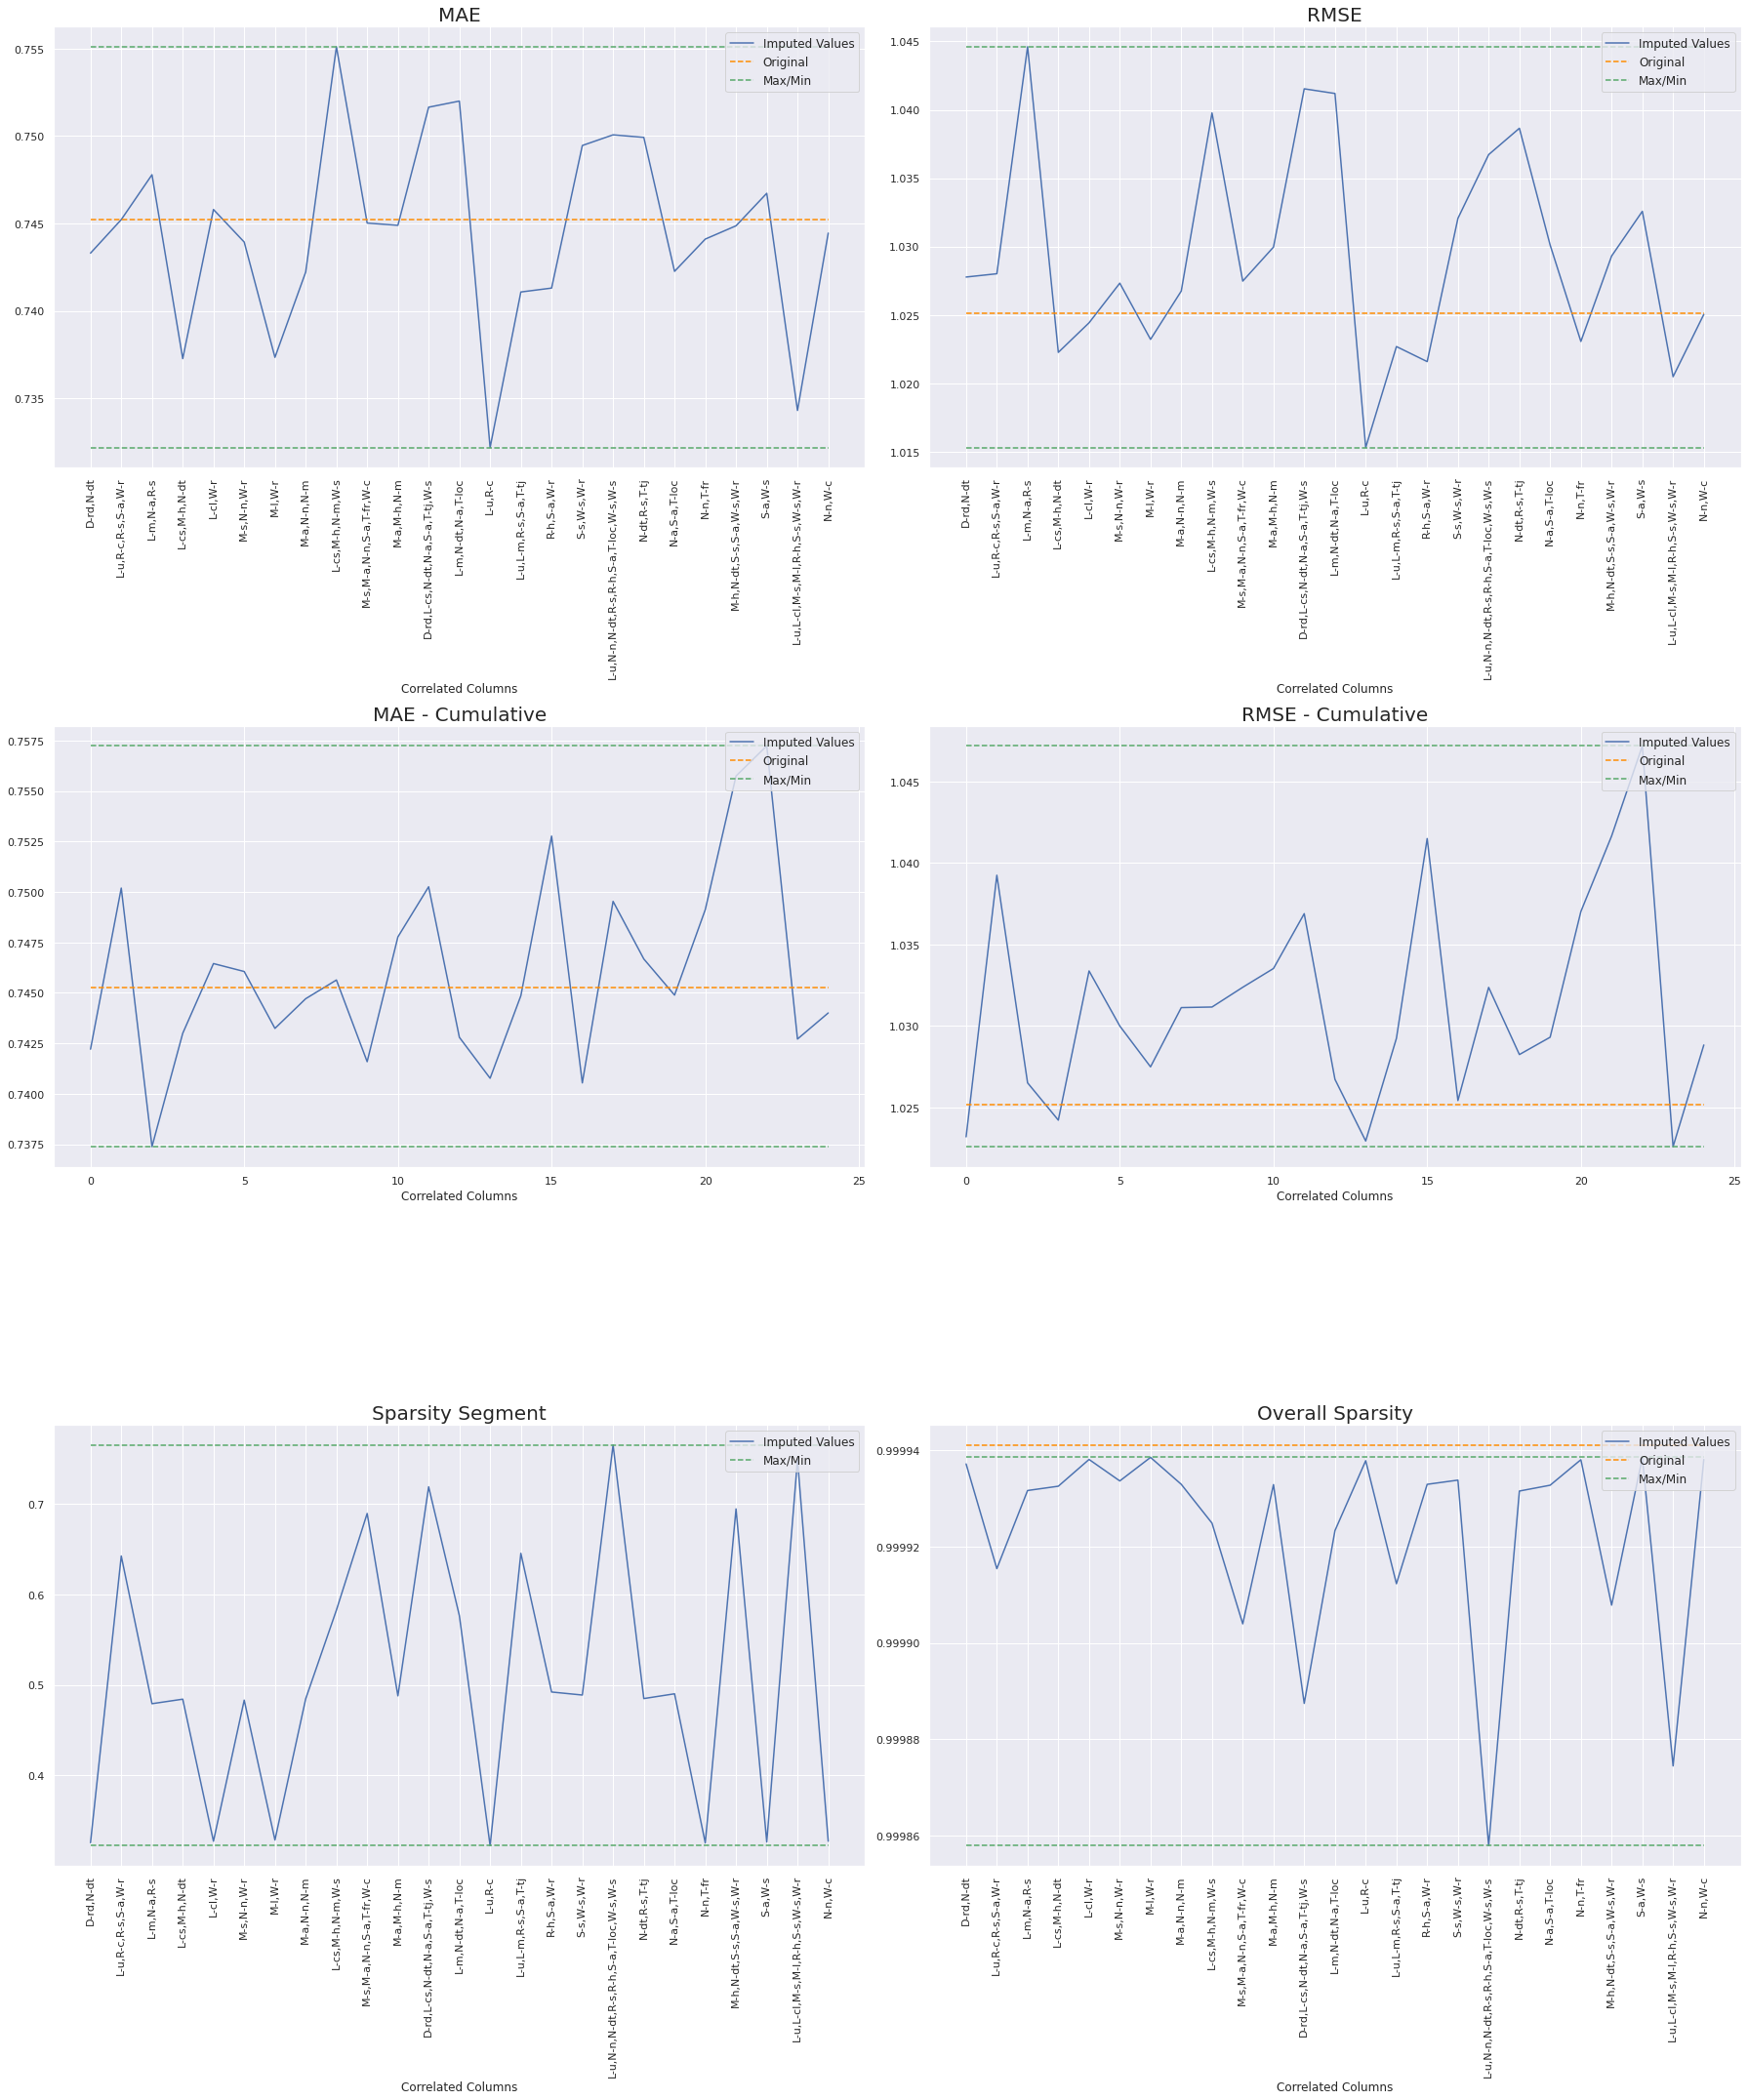

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns )

plot_ALL_MAE_SPARSITY(dict_Test_Results, title_initial_ticks)

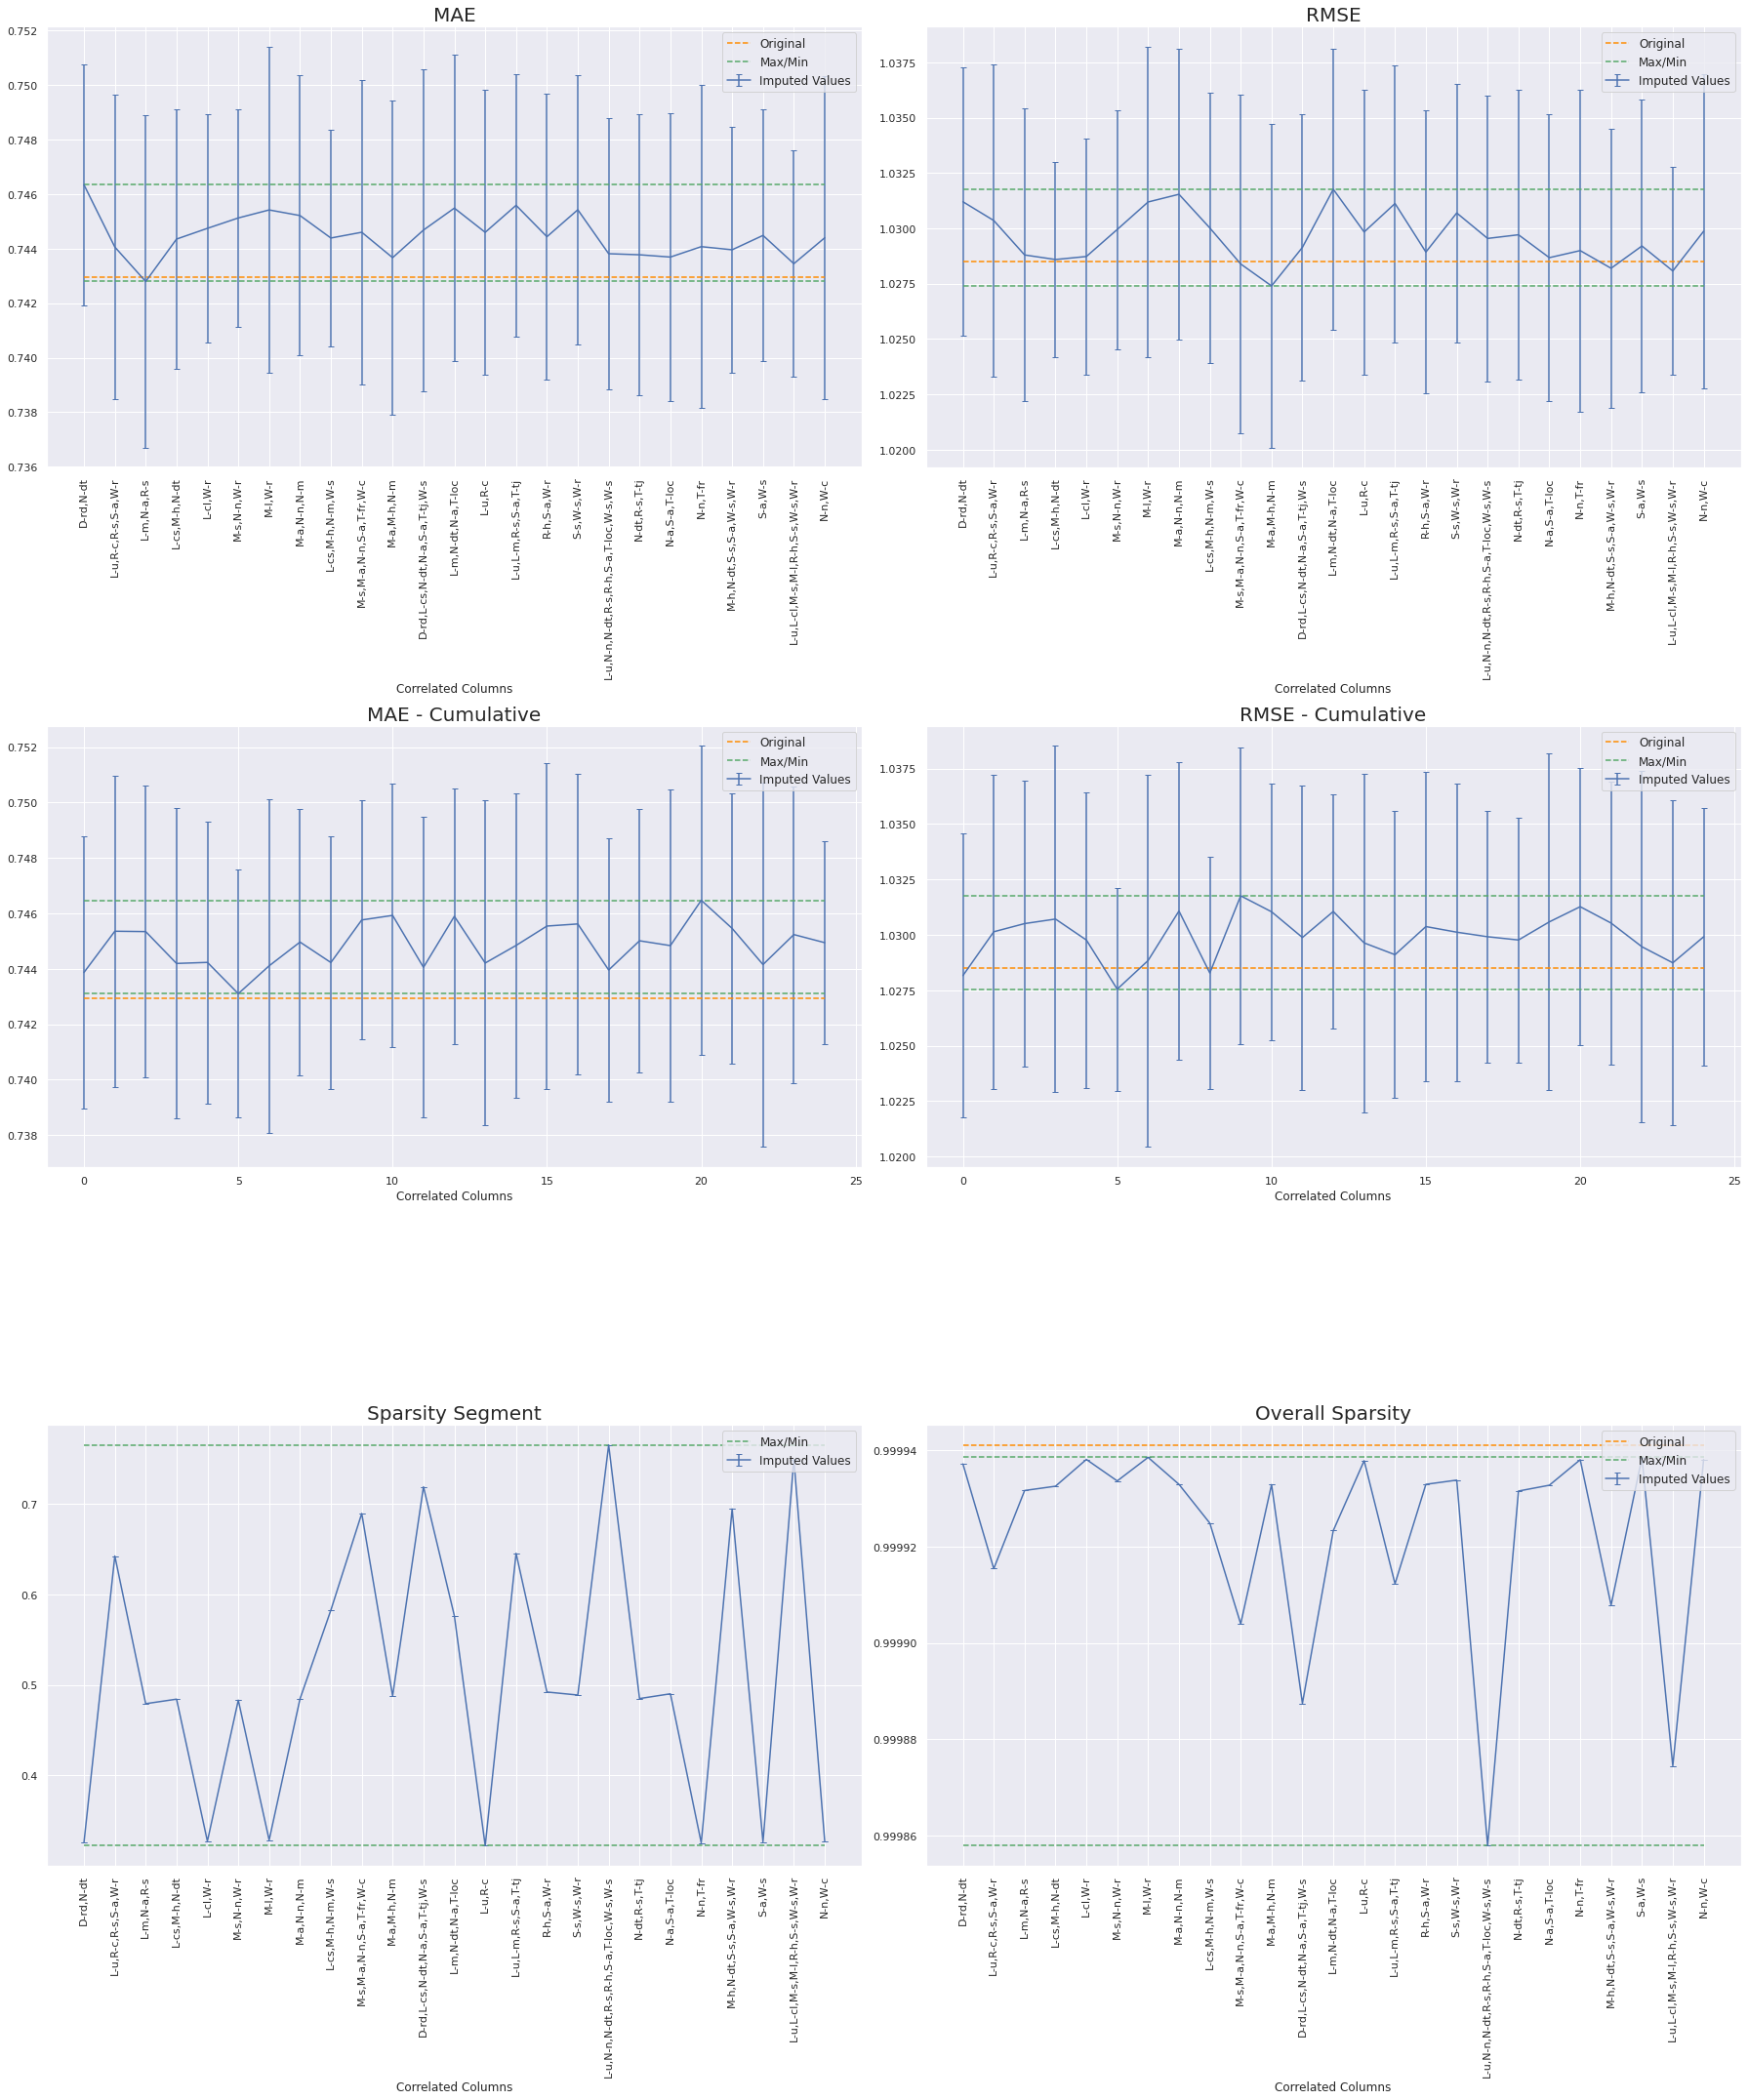

In [ ]:
# Collect the Initials of Title of Columns:
dict_titles_initial = create_dict_for_initial_of_values(df)
title_initial_ticks = replace_names_for_initial(dict_titles_initial, lst_correlated_columns2 )

plot_ALL_MAE_SPARSITY(dict_Test_Results2, title_initial_ticks)

#SCI-kit Imputer



In [ ]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imp = IterativeImputer(max_iter=10, random_state=0)

In [ ]:
df

,UserID,ItemID,Rating,DrivingStyle,landscape,mood,naturalphenomena,RoadType,sleepiness,trafficConditions,weather
0,1001,715,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
1,1001,267,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
2,1001,294,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sunny
3,1001,259,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snowing
4,1001,674,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rainy
...,...,...,...,...,...,...,...,...,...,...,...
4007,1042,716,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4008,1042,733,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4009,1042,682,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4010,1042,691,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#TESTS


In [ ]:
for _ in range(0,10):
  print(CARSKit_test(df_train))

(0.74434, 1.030063)
(0.747212, 1.035043)
(0.736517, 1.01613)
(0.740863, 1.023339)
(0.756722, 1.040455)
(0.736668, 1.021421)
(0.754327, 1.033411)
(0.750988, 1.033345)
(0.745085, 1.033234)
(0.755254, 1.038994)


In [ ]:
for _ in range(0,10):
  print(CARSKit_test(df_train))

(0.754162, 1.037214)
(0.743905, 1.029887)
(0.741378, 1.024912)
(0.737043, 1.027673)
(0.74233, 1.029699)
(0.745019, 1.026043)
(0.752338, 1.042189)
(0.744042, 1.0303)
(0.738068, 1.024974)
(0.741511, 1.02675)


In [ ]:
!java -jar /content/CARSKit/jar/CARSKit-v0.3.5.jar -c /content/drive/My\ Drive/CARS/Datasets/setting_Train_Test.conf

[INFO ] 2020-07-24 16:06:41,179 -- WorkingPath: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace_All/
[INFO ] 2020-07-24 16:06:41,187 -- Your original rating data path: /content/drive/My Drive/CARS/Datasets/InCarMusic_Train.csv
[INFO ] 2020-07-24 16:06:41,187 -- Current working path: /content/drive/My Drive/CARS/Datasets/CARSKit.Workspace_All/
[INFO ] 2020-07-24 16:06:41,195 -- flags - train: 3, test: 3
[WARN ] 2020-07-24 16:06:41,304 -- You training data is in Compact format. CARSKit is working on transformation on the data format...
[INFO ] 2020-07-24 16:06:41,346 -- User, Item, Rating, drivingstyle:na, drivingstyle:relaxed driving, drivingstyle:sport driving, landscape:coast line, landscape:country side, landscape:mountains, landscape:na, landscape:urban, mood:active, mood:happy, mood:lazy, mood:na, mood:sad, naturalphenomena:afternoon, naturalphenomena:day time, naturalphenomena:morning, naturalphenomena:na, naturalphenomena:night, roadtype:city, roadtype:highway, roadtype:n